File1: Customer_Comment Cleaning

In [2]:
import pandas as pd

# Load the dataset
df = pd.read_csv('data/Customer_comment.csv')

# Display the head
print("Head of the DataFrame:")
display(df.head())

# Display the tail
print("\nTail of the DataFrame:")
display(df.tail())

# Display the info
print("\nInfo of the DataFrame:")
df.info()

# Display the describe
print("\nDescribe of the DataFrame:")
display(df.describe())

Head of the DataFrame:


,Unnamed: 0,flight_number,origin_station_code,destination_station_code,scheduled_departure_date,arrival_delay_group,departure_delay_group,entity,verbatim_text,seat_factor_band,ques_verbatim_text,loyalty_program_level,fleet_type_description,fleet_usage,response_group,sentiments,transformed_text
0,0,950,LHX,SFX,2022-09-01,Early & Ontime,Delayed,Atlantic,There was no salad dressing. The staff informe...,0 to 70,Is there anything else you'd like to share abo...,non-elite,B777-200,Mainline,member,Neutral,salad dress staff inform flight receiv salad d...
1,1,950,LHX,SFX,2022-09-01,Early & Ontime,Delayed,Atlantic,Not a choice.,0 to 70,Is there anything else you'd like to share abo...,NaN,B777-200,Mainline,non-member,Neutral,choic
2,2,1876,FLX,EWX,2022-09-01,Early & Ontime,Early & Ontime,Domestic,More variety and bigger snacks.,90+,Is there anything else you'd like to share abo...,non-elite,A320-200,Mainline,member,Neutral,varieti bigger snack
3,3,5469,SFX,SEX,2022-09-01,Early & Ontime,Early & Ontime,Domestic,Serving pretzels and cookies in first class wa...,90+,Is there anything else you'd like to share abo...,premier gold,ERJ-175,Express,member,Neutral,serv pretzel cooki first class extrem disappoi...
4,4,281,DEX,ANX,2022-09-01,Early & Ontime,Early & Ontime,Domestic,More inflight selections to purchase for full ...,0 to 70,Is there anything else you'd like to share abo...,non-elite,B737-MAX8,Mainline,member,Neutral,inflight select purchas full meal



Tail of the DataFrame:


,Unnamed: 0,flight_number,origin_station_code,destination_station_code,scheduled_departure_date,arrival_delay_group,departure_delay_group,entity,verbatim_text,seat_factor_band,ques_verbatim_text,loyalty_program_level,fleet_type_description,fleet_usage,response_group,sentiments,transformed_text
9419,9419,2175,YYX,ORX,2022-09-30,Early & Ontime,Early & Ontime,Domestic,tapas box needs better pita chips. the provide...,90+,Is there anything else you'd like to share abo...,premier gold,B737-700,Mainline,member,Neutral,tapa box need better pita chip provid chip alw...
9420,9420,680,DEX,GRX,2022-09-30,Delayed,Delayed,Domestic,My flight attendant missed my drink order 2x a...,80+,Is there anything else you'd like to share abo...,global services,B737-900,Mainline,member,Neutral,flight attend miss drink order 2x end never re...
9421,9421,1420,CLX,FLX,2022-09-29,Delayed,Early & Ontime,Domestic,Mo.,70+,Is there anything else you'd like to share abo...,premier platinum,B737-800,Mainline,member,Negative,mo
9422,9422,4746,LAX,EUX,2022-09-30,Early & Ontime,Early & Ontime,Domestic,"without a smartphone, not much to eat. we pack...",80+,Is there anything else you'd like to share abo...,NaN,ERJ-175,Express,non-member,Neutral,without smartphon much eat pack food email foo...
9423,9423,3773,IAX,YOX,2022-09-30,Delayed,Delayed,Domestic,Offering coffee or tea would also be great.,90+,Is there anything else you'd like to share abo...,NaN,CRJ-200,Express,non-member,Neutral,offer coffe tea would also great



Info of the DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9424 entries, 0 to 9423
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Unnamed: 0                9424 non-null   int64 
 1   flight_number             9424 non-null   int64 
 2   origin_station_code       9424 non-null   object
 3   destination_station_code  9424 non-null   object
 4   scheduled_departure_date  9424 non-null   object
 5   arrival_delay_group       9424 non-null   object
 6   departure_delay_group     9424 non-null   object
 7   entity                    9424 non-null   object
 8   verbatim_text             9424 non-null   object
 9   seat_factor_band          9424 non-null   object
 10  ques_verbatim_text        9424 non-null   object
 11  loyalty_program_level     6920 non-null   object
 12  fleet_type_description    9424 non-null   object
 13  fleet_usage               9424 non-null   object
 14  

,Unnamed: 0,flight_number
count,9424.000000,9424.000000
mean,4711.500000,1741.573430
std,2720.618802,1550.550037
min,0.000000,2.000000
25%,2355.750000,614.000000
50%,4711.500000,1286.000000
75%,7067.250000,2261.000000
max,9423.000000,6375.000000


In [3]:
print("\nMissing values per column:")
display(df.isnull().sum())


Missing values per column:


Unnamed: 0                     0
flight_number                  0
origin_station_code            0
destination_station_code       0
scheduled_departure_date       0
arrival_delay_group            0
departure_delay_group          0
entity                         0
verbatim_text                  0
seat_factor_band               0
ques_verbatim_text             0
loyalty_program_level       2504
fleet_type_description         0
fleet_usage                    0
response_group                 0
sentiments                     0
transformed_text            1019
dtype: int64

In [4]:
missing_text_df = df[df['transformed_text'].isnull()]
print("Verbatim text for rows with missing transformed_text:")
display(missing_text_df[['verbatim_text', 'transformed_text']].head())
display(missing_text_df[['verbatim_text', 'transformed_text']].tail())

Verbatim text for rows with missing transformed_text:


,verbatim_text,transformed_text
11,no.,NaN
27,No.,NaN
42,no.,NaN
43,no.,NaN
44,No.,NaN


,verbatim_text,transformed_text
9391,no.,NaN
9394,No.,NaN
9398,No.,NaN
9406,No.,NaN
9413,No.,NaN


In [5]:
df['transformed_text_missing'] = df['transformed_text'].isnull().astype(int)

print("\nValue counts for the new indicator column:")
display(df['transformed_text_missing'].value_counts())


Value counts for the new indicator column:


transformed_text_missing
0    8405
1    1019
Name: count, dtype: int64

In [6]:
df['loyalty_program_level'] = df['loyalty_program_level'].fillna('Unknown')

print("\nMissing values after handling loyalty_program_level:")
display(df.isnull().sum())


Missing values after handling loyalty_program_level:


Unnamed: 0                     0
flight_number                  0
origin_station_code            0
destination_station_code       0
scheduled_departure_date       0
arrival_delay_group            0
departure_delay_group          0
entity                         0
verbatim_text                  0
seat_factor_band               0
ques_verbatim_text             0
loyalty_program_level          0
fleet_type_description         0
fleet_usage                    0
response_group                 0
sentiments                     0
transformed_text            1019
transformed_text_missing       0
dtype: int64

In [7]:
df.drop('Unnamed: 0', axis=1, inplace=True)

print("\nDataFrame after dropping 'Unnamed: 0':")
display(df.head())


DataFrame after dropping 'Unnamed: 0':


,flight_number,origin_station_code,destination_station_code,scheduled_departure_date,arrival_delay_group,departure_delay_group,entity,verbatim_text,seat_factor_band,ques_verbatim_text,loyalty_program_level,fleet_type_description,fleet_usage,response_group,sentiments,transformed_text,transformed_text_missing
0,950,LHX,SFX,2022-09-01,Early & Ontime,Delayed,Atlantic,There was no salad dressing. The staff informe...,0 to 70,Is there anything else you'd like to share abo...,non-elite,B777-200,Mainline,member,Neutral,salad dress staff inform flight receiv salad d...,0
1,950,LHX,SFX,2022-09-01,Early & Ontime,Delayed,Atlantic,Not a choice.,0 to 70,Is there anything else you'd like to share abo...,Unknown,B777-200,Mainline,non-member,Neutral,choic,0
2,1876,FLX,EWX,2022-09-01,Early & Ontime,Early & Ontime,Domestic,More variety and bigger snacks.,90+,Is there anything else you'd like to share abo...,non-elite,A320-200,Mainline,member,Neutral,varieti bigger snack,0
3,5469,SFX,SEX,2022-09-01,Early & Ontime,Early & Ontime,Domestic,Serving pretzels and cookies in first class wa...,90+,Is there anything else you'd like to share abo...,premier gold,ERJ-175,Express,member,Neutral,serv pretzel cooki first class extrem disappoi...,0
4,281,DEX,ANX,2022-09-01,Early & Ontime,Early & Ontime,Domestic,More inflight selections to purchase for full ...,0 to 70,Is there anything else you'd like to share abo...,non-elite,B737-MAX8,Mainline,member,Neutral,inflight select purchas full meal,0


In [8]:
print("Number of duplicate rows before dropping:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("Number of duplicate rows after dropping:", df.duplicated().sum())

Number of duplicate rows before dropping: 2
Number of duplicate rows after dropping: 0


In [9]:
df['scheduled_departure_date'] = pd.to_datetime(df['scheduled_departure_date'])

print("\nData types after converting scheduled_departure_date:")
display(df.info())


Data types after converting scheduled_departure_date:
<class 'pandas.core.frame.DataFrame'>
Index: 9422 entries, 0 to 9423
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   flight_number             9422 non-null   int64         
 1   origin_station_code       9422 non-null   object        
 2   destination_station_code  9422 non-null   object        
 3   scheduled_departure_date  9422 non-null   datetime64[ns]
 4   arrival_delay_group       9422 non-null   object        
 5   departure_delay_group     9422 non-null   object        
 6   entity                    9422 non-null   object        
 7   verbatim_text             9422 non-null   object        
 8   seat_factor_band          9422 non-null   object        
 9   ques_verbatim_text        9422 non-null   object        
 10  loyalty_program_level     9422 non-null   object        
 11  fleet_type_description    9422 n

None

File2: Passenger_booking Cleaning

In [10]:
# Load the dataset
df2 = pd.read_csv('data/Passanger_booking_data.csv')

# Display the head
print("Head of the DataFrame:")
display(df2.head())

# Display the tail
print("\nTail of the DataFrame:")
display(df2.tail())

# Display the info
print("\nInfo of the DataFrame:")
df2.info()

# Display the describe
print("\nDescribe of the DataFrame:")
display(df2.describe())

Head of the DataFrame:


,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,1,Internet,RoundTrip,21,12,6,Tue,AKLHGH,Australia,0,0,0,7.21,1
1,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
2,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
3,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
4,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0



Tail of the DataFrame:


,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
49997,2,Internet,RoundTrip,27,6,9,Sat,PERPNH,Australia,1,0,1,5.62,0
49998,1,Internet,RoundTrip,111,6,4,Sun,PERPNH,Australia,0,0,0,5.62,0
49999,1,Internet,RoundTrip,24,6,22,Sat,PERPNH,Australia,0,0,1,5.62,0
50000,1,Internet,RoundTrip,15,6,11,Mon,PERPNH,Australia,1,0,1,5.62,0
50001,1,Internet,RoundTrip,19,6,10,Thu,PERPNH,Australia,0,1,0,5.62,0



Info of the DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50002 entries, 0 to 50001
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50002 non-null  int64  
 1   sales_channel          50002 non-null  object 
 2   trip_type              50002 non-null  object 
 3   purchase_lead          50002 non-null  int64  
 4   length_of_stay         50002 non-null  int64  
 5   flight_hour            50002 non-null  int64  
 6   flight_day             50002 non-null  object 
 7   route                  50002 non-null  object 
 8   booking_origin         50002 non-null  object 
 9   wants_extra_baggage    50002 non-null  int64  
 10  wants_preferred_seat   50002 non-null  int64  
 11  wants_in_flight_meals  50002 non-null  int64  
 12  flight_duration        50002 non-null  float64
 13  booking_complete       50002 non-null  int64  
dtypes: float64(1), int64(8), objec

,num_passengers,purchase_lead,length_of_stay,flight_hour,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
count,50002.000000,50002.000000,50002.000000,50002.000000,50002.000000,50002.000000,50002.000000,50002.000000,50002.000000
mean,1.591256,84.940582,23.044778,9.066277,0.668773,0.296968,0.427143,7.277524,0.149574
std,1.020167,90.450548,33.887171,5.412569,0.470659,0.456927,0.494668,1.496854,0.356657
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.670000,0.000000
25%,1.000000,21.000000,5.000000,5.000000,0.000000,0.000000,0.000000,5.620000,0.000000
50%,1.000000,51.000000,17.000000,9.000000,1.000000,0.000000,0.000000,7.570000,0.000000
75%,2.000000,115.000000,28.000000,13.000000,1.000000,1.000000,1.000000,8.830000,0.000000
max,9.000000,867.000000,778.000000,23.000000,1.000000,1.000000,1.000000,9.500000,1.000000


In [11]:
print("\nMissing values per column:")
display(df2.isnull().sum())


Missing values per column:


num_passengers           0
sales_channel            0
trip_type                0
purchase_lead            0
length_of_stay           0
flight_hour              0
flight_day               0
route                    0
booking_origin           0
wants_extra_baggage      0
wants_preferred_seat     0
wants_in_flight_meals    0
flight_duration          0
booking_complete         0
dtype: int64

In [12]:
print("Number of duplicate rows before dropping:", df2.duplicated().sum())

df2.drop_duplicates(inplace=True)

print("Number of duplicate rows after dropping:", df2.duplicated().sum())

Number of duplicate rows before dropping: 719
Number of duplicate rows after dropping: 0


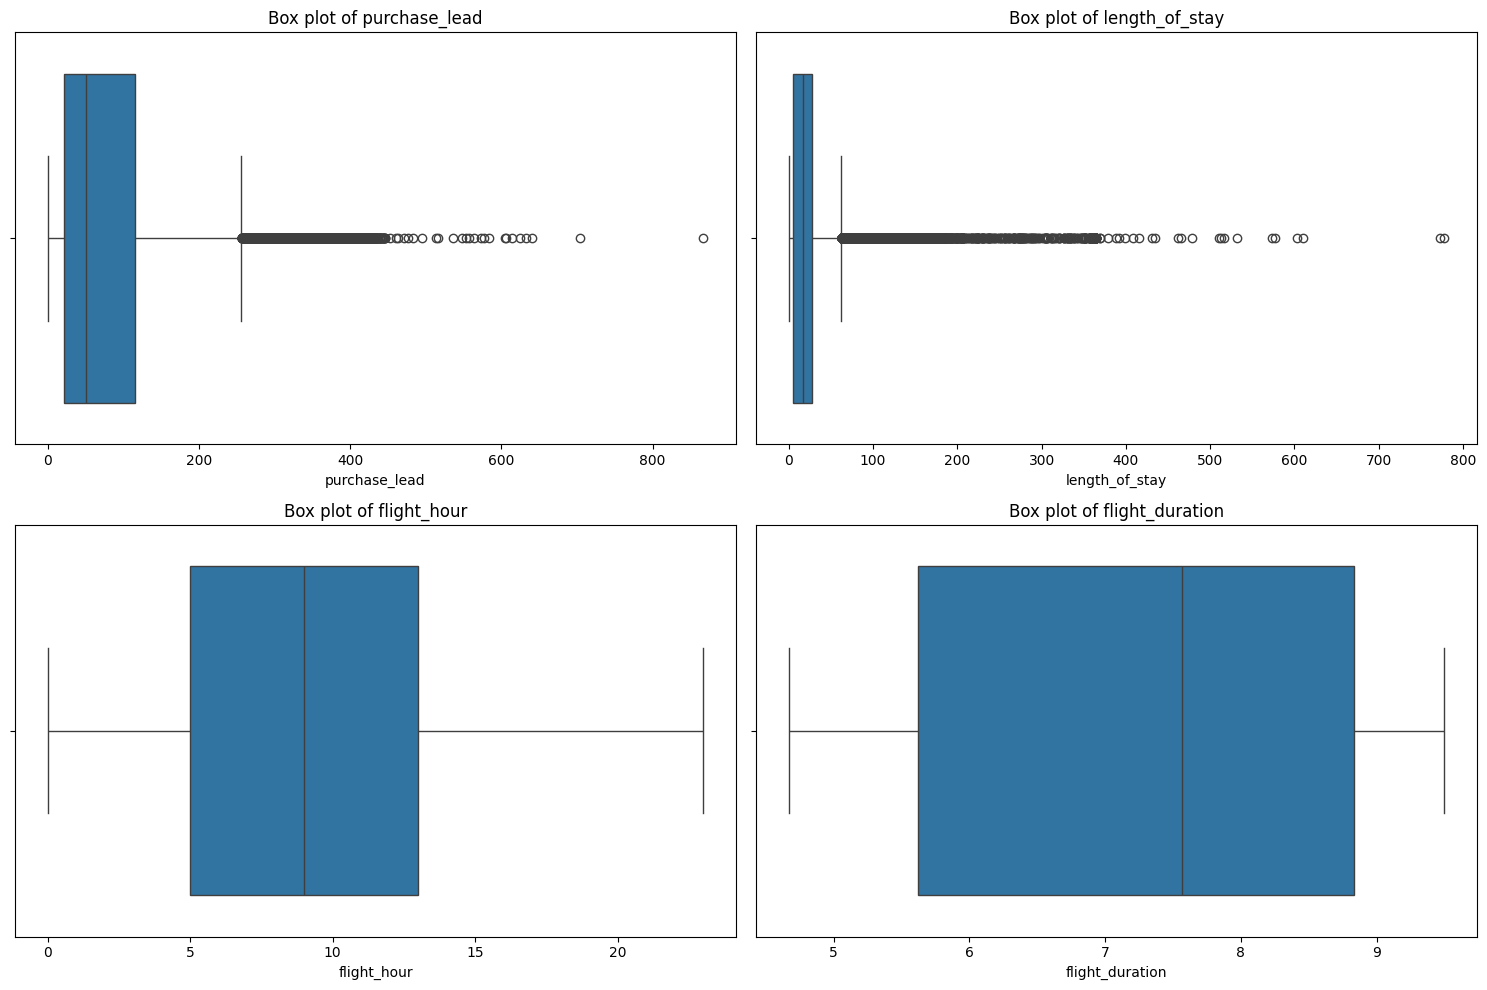

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = ['purchase_lead', 'length_of_stay', 'flight_hour', 'flight_duration']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(x=df2[col])
    plt.title(f'Box plot of {col}')
plt.tight_layout()
plt.show()

In [14]:
# Investigate outliers in 'purchase_lead'
print("Rows with high 'purchase_lead' values:")
display(df2[df2['purchase_lead'] > 600].head()) # Displaying rows with purchase_lead > 600 as outliers are beyond this based on the box plot

# Investigate outliers in 'length_of_stay'
print("\nRows with high 'length_of_stay' values:")
display(df2[df2['length_of_stay'] > 500].head()) # Displaying rows with length_of_stay > 500 as outliers are beyond this based on the box plot

Rows with high 'purchase_lead' values:


,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
837,3,Internet,RoundTrip,641,46,6,Sun,AKLKUL,Malaysia,1,0,1,8.83,1
6150,1,Internet,RoundTrip,614,19,11,Wed,COKMEL,Australia,0,0,0,8.83,0
24121,1,Internet,RoundTrip,704,23,8,Tue,PNHSYD,Australia,0,0,0,8.58,0
38358,2,Internet,RoundTrip,633,5,10,Sat,HKTOOL,Australia,0,0,1,8.83,0
39419,1,Mobile,RoundTrip,625,5,15,Fri,ICNRGN,Myanmar (Burma),0,0,0,6.62,0



Rows with high 'length_of_stay' values:


,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
1585,2,Internet,RoundTrip,32,603,0,Thu,AKLKUL,Malaysia,0,0,0,8.83,0
10296,1,Internet,RoundTrip,10,610,2,Mon,DMKSYD,Australia,1,1,0,8.58,0
10823,1,Internet,RoundTrip,102,778,8,Wed,DPSMEL,Australia,0,0,0,8.83,1
13216,1,Internet,RoundTrip,20,532,11,Thu,HYDPER,India,1,0,1,5.62,0
13441,1,Mobile,RoundTrip,18,513,10,Sat,HYDSYD,India,1,1,1,8.58,0


In [15]:
# Apply capping to 'purchase_lead' at the 95th percentile
purchase_lead_cap = df2['purchase_lead'].quantile(0.95)
df2['purchase_lead'] = df2['purchase_lead'].clip(upper=purchase_lead_cap)

# Apply capping to 'length_of_stay' at the 95th percentile
length_of_stay_cap = df2['length_of_stay'].quantile(0.95)
df2['length_of_stay'] = df2['length_of_stay'].clip(upper=length_of_stay_cap)

print("Descriptive statistics after capping:")
display(df2[['purchase_lead', 'length_of_stay']].describe())

Descriptive statistics after capping:


,purchase_lead,length_of_stay
count,49283.000000,49283.000000
mean,81.604772,20.710306
std,81.207474,21.818939
min,0.000000,0.000000
25%,21.000000,5.000000
50%,51.000000,17.000000
75%,115.000000,28.000000
max,287.000000,84.000000


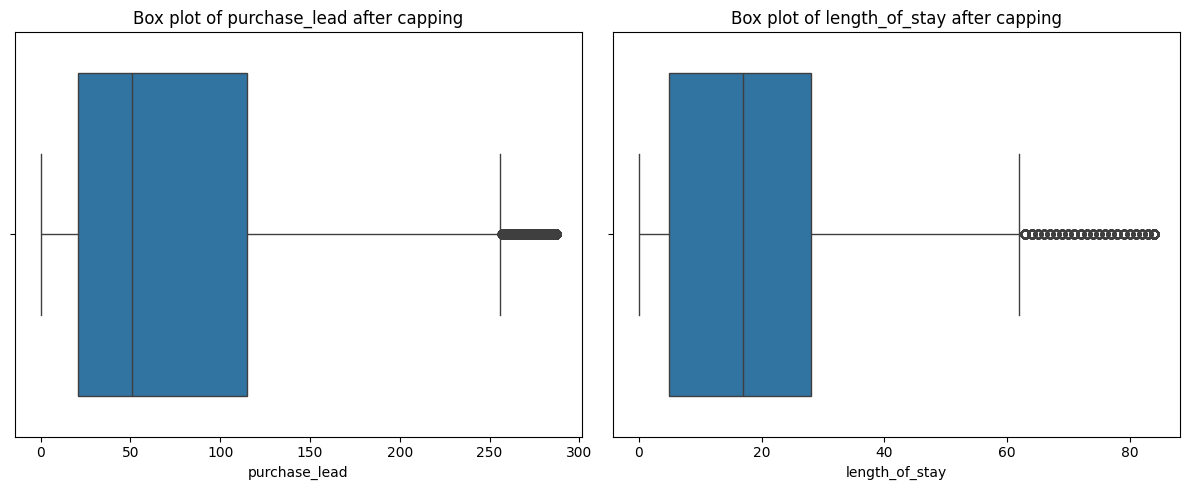

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x=df2['purchase_lead'])
plt.title('Box plot of purchase_lead after capping')

plt.subplot(1, 2, 2)
sns.boxplot(x=df2['length_of_stay'])
plt.title('Box plot of length_of_stay after capping')

plt.tight_layout()
plt.show()

File3: Survey_Data_Inflight_Satisfaction Cleaning

In [17]:
import pandas as pd

# Load the dataset
df3 = pd.read_csv('data/Survey data_Inflight Satisfaction Score.csv')

# Display the head
print("Head of the DataFrame:")
display(df3.head())

# Display the tail
print("\nTail of the DataFrame:")
display(df3.tail())

# Display the info
print("\nInfo of the DataFrame:")
df3.info()

# Display the describe
print("\nDescribe of the DataFrame:")
display(df3.describe())

Head of the DataFrame:


,flight_number,origin_station_code,destination_station_code,record_locator,scheduled_departure_date,question_text,score,satisfaction_type,driver_sub_group1,driver_sub_group2,...,equipment_type_code,ua_uax,actual_flown_miles,haul_type,departure_gate,arrival_gate,international_domestic_indicator,response_group,media_provider,hub_spoke
0,3802,MKX,ORX,CYXXJJ,9/1/2022,How satisfied were you with the food & beverag...,2,Dissatisfied,food & beverage,food and beverage satisfaction,...,CRZ,UAX,67,Short,C12,F10,Domestic,non-member,NaN,spoke departure
1,4645,COX,DEX,DRXXMH,9/1/2022,How satisfied were you with the food & beverag...,5,Satisfied,food & beverage,food and beverage satisfaction,...,E75,UAX,72,Short,5,B60,Domestic,member,GOGO,spoke departure
2,5236,COX,DEX,DEXXS1,9/1/2022,How satisfied were you with the food & beverag...,5,Satisfied,food & beverage,food and beverage satisfaction,...,E75,UAX,72,Short,7,A71,Domestic,member,GOGO,spoke departure
3,4686,DEX,COX,PXXXLH,9/1/2022,How satisfied were you with the food & beverag...,3,Dissatisfied,food & beverage,food and beverage satisfaction,...,CRJ,UAX,72,Short,B82,5,Domestic,member,NaN,hub departure
4,671,DEX,COX,KZXXH5,9/1/2022,How satisfied were you with the food & beverag...,5,Satisfied,food & beverage,food and beverage satisfaction,...,19F,UA,72,Short,B24,3,Domestic,member,PANASONIC,hub departure



Tail of the DataFrame:


,flight_number,origin_station_code,destination_station_code,record_locator,scheduled_departure_date,question_text,score,satisfaction_type,driver_sub_group1,driver_sub_group2,...,equipment_type_code,ua_uax,actual_flown_miles,haul_type,departure_gate,arrival_gate,international_domestic_indicator,response_group,media_provider,hub_spoke
47069,2,SFX,SIX,IPXXM3,9/30/2022,How satisfied were you with the food & beverag...,4,Satisfied,food & beverage,food and beverage satisfaction,...,78P,UA,8440,Long,G9,F52,International,non-member,PANASONIC,hub departure
47070,2,SFX,SIX,O5XXK4,9/30/2022,How satisfied were you with the food & beverag...,4,Satisfied,food & beverage,food and beverage satisfaction,...,78P,UA,8440,Long,G9,F52,International,member,PANASONIC,hub departure
47071,3,SIX,SFX,G8XX3W,9/30/2022,How satisfied were you with the food & beverag...,1,Dissatisfied,food & beverage,food and beverage satisfaction,...,78P,UA,8440,Long,F52,G2,International,member,PANASONIC,spoke departure
47072,3,SIX,SFX,G8XX3W,9/30/2022,What item did you choose?,chicken entrée,NaN,food & beverage,comp,...,78P,UA,8440,Long,F52,G2,International,member,PANASONIC,spoke departure
47073,2,SFX,SIX,O5XXK4,9/30/2022,What item did you choose?,chicken entrée,NaN,food & beverage,comp,...,78P,UA,8440,Long,G9,F52,International,member,PANASONIC,hub departure



Info of the DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47074 entries, 0 to 47073
Data columns (total 31 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   flight_number                     47074 non-null  int64 
 1   origin_station_code               47074 non-null  object
 2   destination_station_code          47074 non-null  object
 3   record_locator                    47074 non-null  object
 4   scheduled_departure_date          47074 non-null  object
 5   question_text                     47074 non-null  object
 6   score                             47074 non-null  object
 7   satisfaction_type                 34963 non-null  object
 8   driver_sub_group1                 47074 non-null  object
 9   driver_sub_group2                 47074 non-null  object
 10  arrival_delay_minutes             47074 non-null  int64 
 11  arrival_delay_group               47074 non-null  object

,flight_number,arrival_delay_minutes,number_of_legs,actual_flown_miles
count,47074.000000,47074.000000,47074.000000,47074.000000
mean,1529.855207,-1.702490,1.344118,2477.737732
std,1456.712299,37.868177,0.502424,1865.646538
min,2.000000,-104.000000,1.000000,45.000000
25%,477.000000,-19.000000,1.000000,932.000000
50%,1050.000000,-9.000000,1.000000,1846.000000
75%,2060.000000,4.000000,2.000000,3870.000000
max,6376.000000,907.000000,3.000000,8440.000000


In [18]:
print("\nMissing values per column:")
display(df3.isnull().sum())


Missing values per column:


flight_number                           0
origin_station_code                     0
destination_station_code                0
record_locator                          0
scheduled_departure_date                0
question_text                           0
score                                   0
satisfaction_type                   12111
driver_sub_group1                       0
driver_sub_group2                       0
arrival_delay_minutes                   0
arrival_delay_group                     0
cabin_code_desc                         0
cabin_name                          19980
entity                                  3
number_of_legs                          0
seat_factor_band                        0
loyalty_program_level               11616
generation                              0
fleet_type_description                  0
fleet_usage                             0
equipment_type_code                     0
ua_uax                                  0
actual_flown_miles                

In [19]:
df3['satisfaction_type'] = df3['satisfaction_type'].fillna('Non-Scored Feedback')

print("\nMissing values after filling remaining satisfaction_type:")
display(df3.isnull().sum())

print("\nValue counts for satisfaction_type after filling:")
display(df3['satisfaction_type'].value_counts())


Missing values after filling remaining satisfaction_type:


flight_number                           0
origin_station_code                     0
destination_station_code                0
record_locator                          0
scheduled_departure_date                0
question_text                           0
score                                   0
satisfaction_type                       0
driver_sub_group1                       0
driver_sub_group2                       0
arrival_delay_minutes                   0
arrival_delay_group                     0
cabin_code_desc                         0
cabin_name                          19980
entity                                  3
number_of_legs                          0
seat_factor_band                        0
loyalty_program_level               11616
generation                              0
fleet_type_description                  0
fleet_usage                             0
equipment_type_code                     0
ua_uax                                  0
actual_flown_miles                


Value counts for satisfaction_type after filling:


satisfaction_type
Dissatisfied           22353
Satisfied              12610
Non-Scored Feedback    12111
Name: count, dtype: int64

In [20]:
# Filter for rows where satisfaction_type is still missing
remaining_missing_satisfaction = df3[df3['satisfaction_type'].isnull()]

# Display the unique values and their counts in the 'score' column for these rows
print("Score values for rows where satisfaction_type is still missing:")
display(remaining_missing_satisfaction['score'].value_counts(dropna=False))

# Optionally, display a few of these rows to see the full context
print("\nSample rows where satisfaction_type is still missing:")
display(remaining_missing_satisfaction[['score', 'satisfaction_type', 'question_text']].head())

Score values for rows where satisfaction_type is still missing:


Series([], Name: count, dtype: int64)


Sample rows where satisfaction_type is still missing:


,score,satisfaction_type,question_text


In [21]:
print("\nMissing values per column in df3:")
display(df3.isnull().sum())


Missing values per column in df3:


flight_number                           0
origin_station_code                     0
destination_station_code                0
record_locator                          0
scheduled_departure_date                0
question_text                           0
score                                   0
satisfaction_type                       0
driver_sub_group1                       0
driver_sub_group2                       0
arrival_delay_minutes                   0
arrival_delay_group                     0
cabin_code_desc                         0
cabin_name                          19980
entity                                  3
number_of_legs                          0
seat_factor_band                        0
loyalty_program_level               11616
generation                              0
fleet_type_description                  0
fleet_usage                             0
equipment_type_code                     0
ua_uax                                  0
actual_flown_miles                

In [22]:
df3.drop('cabin_name', axis=1, inplace=True)

print("\nDataFrame after dropping 'cabin_name':")
display(df3.head())
print("\nMissing values after dropping 'cabin_name':")
display(df3.isnull().sum())


DataFrame after dropping 'cabin_name':


,flight_number,origin_station_code,destination_station_code,record_locator,scheduled_departure_date,question_text,score,satisfaction_type,driver_sub_group1,driver_sub_group2,...,equipment_type_code,ua_uax,actual_flown_miles,haul_type,departure_gate,arrival_gate,international_domestic_indicator,response_group,media_provider,hub_spoke
0,3802,MKX,ORX,CYXXJJ,9/1/2022,How satisfied were you with the food & beverag...,2,Dissatisfied,food & beverage,food and beverage satisfaction,...,CRZ,UAX,67,Short,C12,F10,Domestic,non-member,NaN,spoke departure
1,4645,COX,DEX,DRXXMH,9/1/2022,How satisfied were you with the food & beverag...,5,Satisfied,food & beverage,food and beverage satisfaction,...,E75,UAX,72,Short,5,B60,Domestic,member,GOGO,spoke departure
2,5236,COX,DEX,DEXXS1,9/1/2022,How satisfied were you with the food & beverag...,5,Satisfied,food & beverage,food and beverage satisfaction,...,E75,UAX,72,Short,7,A71,Domestic,member,GOGO,spoke departure
3,4686,DEX,COX,PXXXLH,9/1/2022,How satisfied were you with the food & beverag...,3,Dissatisfied,food & beverage,food and beverage satisfaction,...,CRJ,UAX,72,Short,B82,5,Domestic,member,NaN,hub departure
4,671,DEX,COX,KZXXH5,9/1/2022,How satisfied were you with the food & beverag...,5,Satisfied,food & beverage,food and beverage satisfaction,...,19F,UA,72,Short,B24,3,Domestic,member,PANASONIC,hub departure



Missing values after dropping 'cabin_name':


flight_number                           0
origin_station_code                     0
destination_station_code                0
record_locator                          0
scheduled_departure_date                0
question_text                           0
score                                   0
satisfaction_type                       0
driver_sub_group1                       0
driver_sub_group2                       0
arrival_delay_minutes                   0
arrival_delay_group                     0
cabin_code_desc                         0
entity                                  3
number_of_legs                          0
seat_factor_band                        0
loyalty_program_level               11616
generation                              0
fleet_type_description                  0
fleet_usage                             0
equipment_type_code                     0
ua_uax                                  0
actual_flown_miles                      0
haul_type                         

In [23]:
# Filter for rows where satisfaction_type is not missing
satisfaction_present_df = df3.dropna(subset=['satisfaction_type'])

# Display unique combinations of score and satisfaction_type
print("Unique combinations of score and satisfaction_type (where satisfaction_type is present):")
display(satisfaction_present_df[['score', 'satisfaction_type']].drop_duplicates().sort_values(by='score'))

Unique combinations of score and satisfaction_type (where satisfaction_type is present):


,score,satisfaction_type
8,1,Dissatisfied
0,2,Dissatisfied
3,3,Dissatisfied
25,4,Satisfied
1,5,Satisfied
347,beef entrée,Non-Scored Feedback
82,chicken entrée,Non-Scored Feedback
272,other (specify),Non-Scored Feedback
331,sandwich/burger/wrap,Non-Scored Feedback
990,seafood entrée,Non-Scored Feedback


In [24]:
df3['arrival_gate'] = df3['arrival_gate'].fillna('Unknown')

print("\nMissing values after handling arrival_gate:")
display(df3.isnull().sum())


Missing values after handling arrival_gate:


flight_number                           0
origin_station_code                     0
destination_station_code                0
record_locator                          0
scheduled_departure_date                0
question_text                           0
score                                   0
satisfaction_type                       0
driver_sub_group1                       0
driver_sub_group2                       0
arrival_delay_minutes                   0
arrival_delay_group                     0
cabin_code_desc                         0
entity                                  3
number_of_legs                          0
seat_factor_band                        0
loyalty_program_level               11616
generation                              0
fleet_type_description                  0
fleet_usage                             0
equipment_type_code                     0
ua_uax                                  0
actual_flown_miles                      0
haul_type                         

In [25]:
df3.dropna(subset=['departure_gate'], inplace=True)

print("\nMissing values after dropping rows with missing 'departure_gate':")
display(df3.isnull().sum())


Missing values after dropping rows with missing 'departure_gate':


flight_number                           0
origin_station_code                     0
destination_station_code                0
record_locator                          0
scheduled_departure_date                0
question_text                           0
score                                   0
satisfaction_type                       0
driver_sub_group1                       0
driver_sub_group2                       0
arrival_delay_minutes                   0
arrival_delay_group                     0
cabin_code_desc                         0
entity                                  3
number_of_legs                          0
seat_factor_band                        0
loyalty_program_level               11588
generation                              0
fleet_type_description                  0
fleet_usage                             0
equipment_type_code                     0
ua_uax                                  0
actual_flown_miles                      0
haul_type                         

In [26]:
df3['media_provider'] = df3['media_provider'].fillna('Unknown')

print("\nMissing values after handling media_provider:")
display(df3.isnull().sum())


Missing values after handling media_provider:


flight_number                           0
origin_station_code                     0
destination_station_code                0
record_locator                          0
scheduled_departure_date                0
question_text                           0
score                                   0
satisfaction_type                       0
driver_sub_group1                       0
driver_sub_group2                       0
arrival_delay_minutes                   0
arrival_delay_group                     0
cabin_code_desc                         0
entity                                  3
number_of_legs                          0
seat_factor_band                        0
loyalty_program_level               11588
generation                              0
fleet_type_description                  0
fleet_usage                             0
equipment_type_code                     0
ua_uax                                  0
actual_flown_miles                      0
haul_type                         

In [27]:
df3['loyalty_program_level'] = df3['loyalty_program_level'].fillna('Unknown')

print("\nMissing values after handling loyalty_program_level:")
display(df3.isnull().sum())


Missing values after handling loyalty_program_level:


flight_number                       0
origin_station_code                 0
destination_station_code            0
record_locator                      0
scheduled_departure_date            0
question_text                       0
score                               0
satisfaction_type                   0
driver_sub_group1                   0
driver_sub_group2                   0
arrival_delay_minutes               0
arrival_delay_group                 0
cabin_code_desc                     0
entity                              3
number_of_legs                      0
seat_factor_band                    0
loyalty_program_level               0
generation                          0
fleet_type_description              0
fleet_usage                         0
equipment_type_code                 0
ua_uax                              0
actual_flown_miles                  0
haul_type                           0
departure_gate                      0
arrival_gate                        0
internationa

In [28]:
df3.dropna(subset=['entity'], inplace=True)

print("\nMissing values after dropping rows with missing 'entity':")
display(df3.isnull().sum())


Missing values after dropping rows with missing 'entity':


flight_number                       0
origin_station_code                 0
destination_station_code            0
record_locator                      0
scheduled_departure_date            0
question_text                       0
score                               0
satisfaction_type                   0
driver_sub_group1                   0
driver_sub_group2                   0
arrival_delay_minutes               0
arrival_delay_group                 0
cabin_code_desc                     0
entity                              0
number_of_legs                      0
seat_factor_band                    0
loyalty_program_level               0
generation                          0
fleet_type_description              0
fleet_usage                         0
equipment_type_code                 0
ua_uax                              0
actual_flown_miles                  0
haul_type                           0
departure_gate                      0
arrival_gate                        0
internationa

In [29]:
print("Number of duplicate rows before dropping:", df3.duplicated().sum())

df3.drop_duplicates(inplace=True)

print("Number of duplicate rows after dropping:", df3.duplicated().sum())

Number of duplicate rows before dropping: 0
Number of duplicate rows after dropping: 0


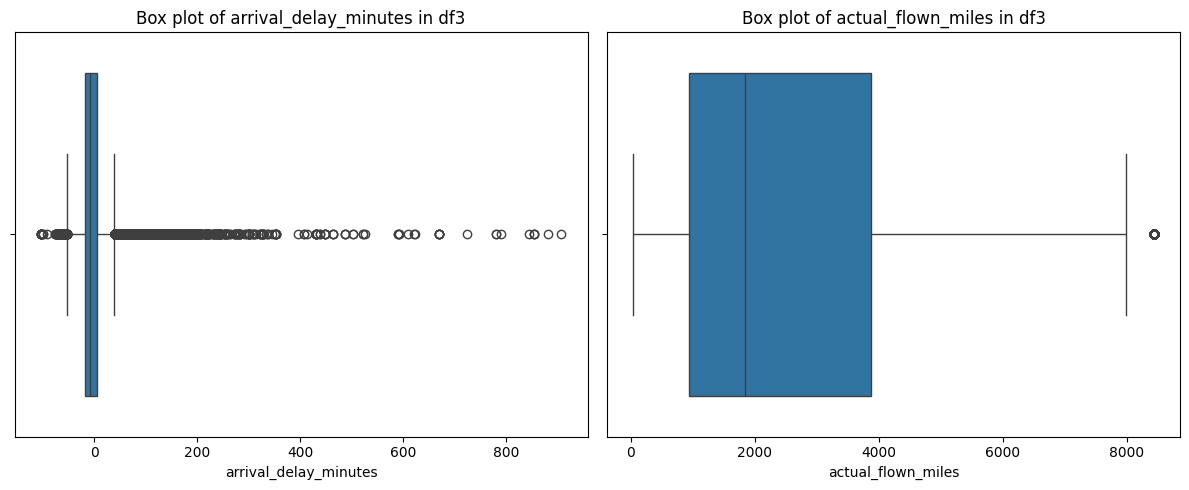

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols_df3 = ['arrival_delay_minutes', 'actual_flown_miles']

plt.figure(figsize=(12, 5))
for i, col in enumerate(numerical_cols_df3):
    plt.subplot(1, 2, i + 1)
    sns.boxplot(x=df3[col])
    plt.title(f'Box plot of {col} in df3')
plt.tight_layout()
plt.show()

File4: AirlineScrappedReview Cleaning

In [31]:
import pandas as pd

# Load the dataset
df4 = pd.read_csv('data/AirlineScrappedReview_Cleaned.csv')

# Display the head
print("Head of the DataFrame:")
display(df4.head())

# Display the tail
print("\nTail of the DataFrame:")
display(df4.tail())

# Display the info
print("\nInfo of the DataFrame:")
df4.info()

# Display the describe
print("\nDescribe of the DataFrame:")
display(df4.describe())

Head of the DataFrame:


,Passanger_Name,Flying_Date,Route,Rating,Verified,Review_title,Review_content,Traveller_Type,Class,Start_Location,End_Location,Layover_Route,Start_Latitude,Start_Longitude,Start_Address,End_Latitude,End_Longitude,End_Address
0,Paige Boet,June 2023,New Orleans to London,1,Trip Verified,The airline lost my luggage,The airline lost my luggage and was absolutely...,Solo Leisure,Economy Class,New Orleans,London,NaN,29.975998,-90.078213,"New Orleans, Orleans Parish, Louisiana, United...",51.507446,-0.127765,"London, Greater London, England, United Kingdom"
1,S Layne,March 2023,London to Amman,1,Trip Verified,fully refunded by our travel insurance,"We booked on the BA website, round trip flight...",Couple Leisure,Business Class,London,Amman,NaN,51.507446,-0.127765,"London, Greater London, England, United Kingdom",31.951569,35.923963,"عمان, ناحية عمان, لواء قصبة عمان, عمان, 11110,..."
2,E Lanewoski,NaN,Heathrow to Bodrum,2,Trip Verified,no boarding drinks provided,"First time flying with BA business class, neve...",Solo Leisure,Business Class,London Heathrow,Bodrum,NaN,51.467739,-0.458780,"London Heathrow Airport, The Beacon Roundabout...",37.034399,27.430651,"Bodrum, Muğla, Ege Bölgesi, Türkiye"
3,Joel Burman,June 2023,Amman to London,4,Not Verified,WiFi didn't work,You can buy sandwiches and crisps but don't ex...,Solo Leisure,Economy Class,Amman,London,NaN,31.951569,35.923963,"عمان, ناحية عمان, لواء قصبة عمان, عمان, 11110,...",51.507446,-0.127765,"London, Greater London, England, United Kingdom"
4,R Vines,NaN,London City to Ibiza,7,Trip Verified,stick with economy,This is a two-for-one review covering economy ...,Family Leisure,Business Class,London City,Ibiza,NaN,42.953765,-81.229153,"London (city), Ontario, N6C 0A7, Canada",38.974390,1.419746,"Eivissa, Illes Balears, España"



Tail of the DataFrame:


,Passanger_Name,Flying_Date,Route,Rating,Verified,Review_title,Review_content,Traveller_Type,Class,Start_Location,End_Location,Layover_Route,Start_Latitude,Start_Longitude,Start_Address,End_Latitude,End_Longitude,End_Address
3570,W Benson,NaN,NaN,4,Not Verified,British Airways customer review,LHR-HKG on Boeing 747 - 23/08/12. Much has bee...,Unknown,Economy Class,NaN,NaN,NaN,46.314475,11.048029,"Nanno, Ville d'Anaunia, Comunità della Val di ...",46.314475,11.048029,"Nanno, Ville d'Anaunia, Comunità della Val di ..."
3571,S Luqman,NaN,NaN,4,Not Verified,British Airways customer review,Just got back from Bridgetown Barbados flying ...,Unknown,Economy Class,NaN,NaN,NaN,46.314475,11.048029,"Nanno, Ville d'Anaunia, Comunità della Val di ...",46.314475,11.048029,"Nanno, Ville d'Anaunia, Comunità della Val di ..."
3572,D Smith,NaN,NaN,4,Not Verified,British Airways customer review,LHR-JFK-LAX-LHR. Check in was ok apart from be...,Unknown,Economy Class,NaN,NaN,NaN,46.314475,11.048029,"Nanno, Ville d'Anaunia, Comunità della Val di ...",46.314475,11.048029,"Nanno, Ville d'Anaunia, Comunità della Val di ..."
3573,W Benson,NaN,NaN,6,Not Verified,British Airways customer review,HKG-LHR in New Club World on Boeing 777-300 - ...,Unknown,Business Class,NaN,NaN,NaN,46.314475,11.048029,"Nanno, Ville d'Anaunia, Comunità della Val di ...",46.314475,11.048029,"Nanno, Ville d'Anaunia, Comunità della Val di ..."
3574,Michael Dielissen,NaN,NaN,8,Not Verified,British Airways customer review,YYZ to LHR - July 2012 - I flew overnight in p...,Unknown,Premium Economy,NaN,NaN,NaN,46.314475,11.048029,"Nanno, Ville d'Anaunia, Comunità della Val di ...",46.314475,11.048029,"Nanno, Ville d'Anaunia, Comunità della Val di ..."



Info of the DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3575 entries, 0 to 3574
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Passanger_Name   3574 non-null   object 
 1   Flying_Date      955 non-null    object 
 2   Route            2809 non-null   object 
 3   Rating           3575 non-null   int64  
 4   Verified         3575 non-null   object 
 5   Review_title     3575 non-null   object 
 6   Review_content   3575 non-null   object 
 7   Traveller_Type   3575 non-null   object 
 8   Class            3575 non-null   object 
 9   Start_Location   2809 non-null   object 
 10  End_Location     2809 non-null   object 
 11  Layover_Route    484 non-null    object 
 12  Start_Latitude   3515 non-null   float64
 13  Start_Longitude  3515 non-null   float64
 14  Start_Address    3515 non-null   object 
 15  End_Latitude     3476 non-null   float64
 16  End_Longitude    3476 non-null   flo

,Rating,Start_Latitude,Start_Longitude,End_Latitude,End_Longitude
count,3575.000000,3515.000000,3515.000000,3476.000000,3476.000000
mean,4.790490,42.639473,-2.164986,40.550399,-1.118816
std,3.170323,17.022014,44.576587,18.723619,46.045735
min,1.000000,-37.666951,-123.182909,-37.814245,-123.179234
25%,2.000000,41.893320,-0.458780,39.739236,-0.458780
50%,4.000000,46.314475,-0.127765,46.314475,-0.127765
75%,8.000000,51.467739,11.048029,51.467739,11.048029
max,10.000000,65.011873,151.208285,64.145981,174.550610


In [32]:
print("\nMissing values per column:")
display(df4.isnull().sum())


Missing values per column:


Passanger_Name        1
Flying_Date        2620
Route               766
Rating                0
Verified              0
Review_title          0
Review_content        0
Traveller_Type        0
Class                 0
Start_Location      766
End_Location        766
Layover_Route      3091
Start_Latitude       60
Start_Longitude      60
Start_Address        60
End_Latitude         99
End_Longitude        99
End_Address          99
dtype: int64

In [33]:
df4.drop('Flying_Date', axis=1, inplace=True)

In [34]:
df4['Layover_Route'] = df4['Layover_Route'].fillna('Direct')

print("\nMissing values after handling Layover_Route:")
display(df4.isnull().sum())


Missing values after handling Layover_Route:


Passanger_Name       1
Route              766
Rating               0
Verified             0
Review_title         0
Review_content       0
Traveller_Type       0
Class                0
Start_Location     766
End_Location       766
Layover_Route        0
Start_Latitude      60
Start_Longitude     60
Start_Address       60
End_Latitude        99
End_Longitude       99
End_Address         99
dtype: int64

In [35]:
df4.dropna(subset=['Passanger_Name'], inplace=True)

print("\nMissing values after dropping row with missing 'Passanger_Name':")
display(df4.isnull().sum())


Missing values after dropping row with missing 'Passanger_Name':


Passanger_Name       0
Route              765
Rating               0
Verified             0
Review_title         0
Review_content       0
Traveller_Type       0
Class                0
Start_Location     765
End_Location       765
Layover_Route        0
Start_Latitude      60
Start_Longitude     60
Start_Address       60
End_Latitude        99
End_Longitude       99
End_Address         99
dtype: int64

In [36]:
df4.dropna(subset=['Route', 'Start_Location', 'End_Location'], inplace=True)

print("\nMissing values after dropping rows with missing route/location info:")
display(df4.isnull().sum())


Missing values after dropping rows with missing route/location info:


Passanger_Name      0
Route               0
Rating              0
Verified            0
Review_title        0
Review_content      0
Traveller_Type      0
Class               0
Start_Location      0
End_Location        0
Layover_Route       0
Start_Latitude     60
Start_Longitude    60
Start_Address      60
End_Latitude       99
End_Longitude      99
End_Address        99
dtype: int64

In [37]:
df4.dropna(subset=['Start_Latitude', 'Start_Longitude', 'Start_Address', 'End_Latitude', 'End_Longitude', 'End_Address'], inplace=True)

print("\nMissing values after dropping remaining location info rows:")
display(df4.isnull().sum())


Missing values after dropping remaining location info rows:


Passanger_Name     0
Route              0
Rating             0
Verified           0
Review_title       0
Review_content     0
Traveller_Type     0
Class              0
Start_Location     0
End_Location       0
Layover_Route      0
Start_Latitude     0
Start_Longitude    0
Start_Address      0
End_Latitude       0
End_Longitude      0
End_Address        0
dtype: int64

In [38]:
print("Number of duplicate rows before dropping:", df4.duplicated().sum())

df4.drop_duplicates(inplace=True)

print("Number of duplicate rows after dropping:", df4.duplicated().sum())

Number of duplicate rows before dropping: 2
Number of duplicate rows after dropping: 0


In [39]:
from geopy.distance import great_circle

df4['flight_distance_km'] = df4.apply(
    lambda row: great_circle(
        (row['Start_Latitude'], row['Start_Longitude']),
        (row['End_Latitude'], row['End_Longitude'])
    ).km, axis=1
)
df4['has_layover'] = df4['Layover_Route'].notnull().astype(int)
df4['route_length'] = df4['Route'].apply(lambda x: len(x.split('-')) if isinstance(x, str) else 0)

In [40]:
df4['review_length'] = df4['Review_content'].apply(lambda x: len(str(x)))
df4['word_count'] = df4['Review_content'].apply(lambda x: len(str(x).split()))

In [41]:
print(df4.columns)

Index(['Passanger_Name', 'Route', 'Rating', 'Verified', 'Review_title',
       'Review_content', 'Traveller_Type', 'Class', 'Start_Location',
       'End_Location', 'Layover_Route', 'Start_Latitude', 'Start_Longitude',
       'Start_Address', 'End_Latitude', 'End_Longitude', 'End_Address',
       'flight_distance_km', 'has_layover', 'route_length', 'review_length',
       'word_count'],
      dtype='object')


In [42]:
df4.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2648 entries, 0 to 2814
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Passanger_Name      2648 non-null   object 
 1   Route               2648 non-null   object 
 2   Rating              2648 non-null   int64  
 3   Verified            2648 non-null   object 
 4   Review_title        2648 non-null   object 
 5   Review_content      2648 non-null   object 
 6   Traveller_Type      2648 non-null   object 
 7   Class               2648 non-null   object 
 8   Start_Location      2648 non-null   object 
 9   End_Location        2648 non-null   object 
 10  Layover_Route       2648 non-null   object 
 11  Start_Latitude      2648 non-null   float64
 12  Start_Longitude     2648 non-null   float64
 13  Start_Address       2648 non-null   object 
 14  End_Latitude        2648 non-null   float64
 15  End_Longitude       2648 non-null   float64
 16  End_Address

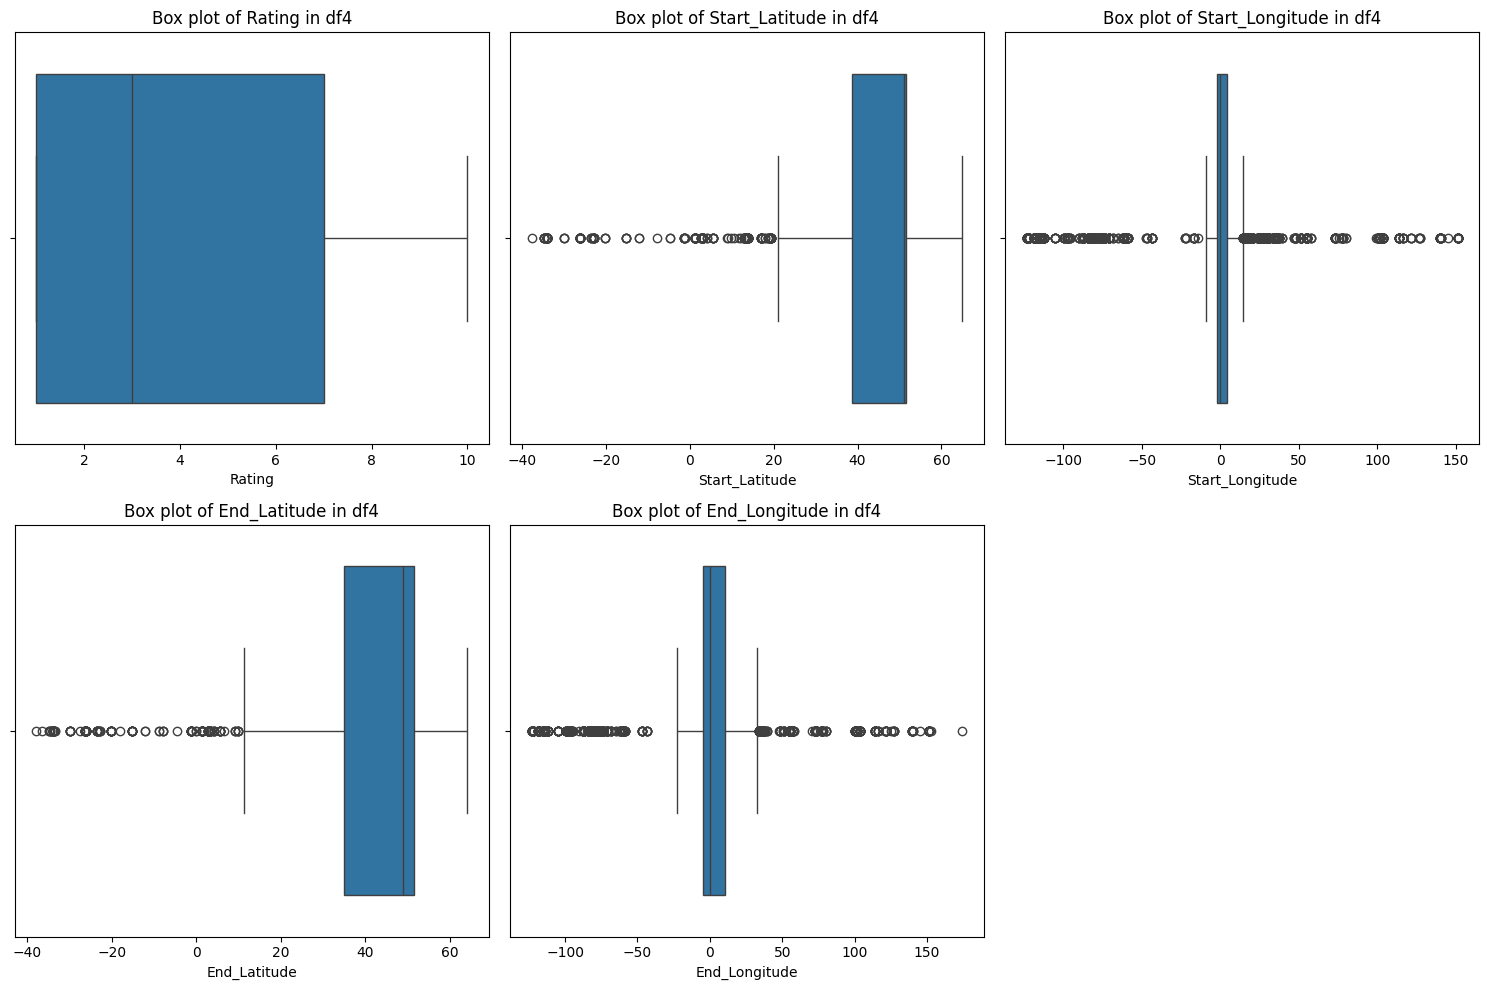

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols_df4 = ['Rating', 'Start_Latitude', 'Start_Longitude', 'End_Latitude', 'End_Longitude']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols_df4):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(x=df4[col])
    plt.title(f'Box plot of {col} in df4')
plt.tight_layout()
plt.show()

In [44]:
# Calculate thresholds for outliers using percentiles
start_lat_lower = df4['Start_Latitude'].quantile(0.01)
start_lat_upper = df4['Start_Latitude'].quantile(0.99)
start_lon_lower = df4['Start_Longitude'].quantile(0.01)
start_lon_upper = df4['Start_Longitude'].quantile(0.99)
end_lat_lower = df4['End_Latitude'].quantile(0.01)
end_lat_upper = df4['End_Latitude'].quantile(0.99)
end_lon_lower = df4['End_Longitude'].quantile(0.01)
end_lon_upper = df4['End_Longitude'].quantile(0.99)

# Filter for rows with outlier coordinates
outlier_coords_df4 = df4[
    (df4['Start_Latitude'] < start_lat_lower) | (df4['Start_Latitude'] > start_lat_upper) |
    (df4['Start_Longitude'] < start_lon_lower) | (df4['Start_Longitude'] > start_lon_upper) |
    (df4['End_Latitude'] < end_lat_lower) | (df4['End_Latitude'] > end_lat_upper) |
    (df4['End_Longitude'] < end_lon_lower) | (df4['End_Longitude'] > end_lon_upper)
]

print("Rows with potential outlier Latitude/Longitude values:")
display(outlier_coords_df4[['Route', 'Start_Location', 'End_Location', 'Start_Latitude', 'Start_Longitude', 'End_Latitude', 'End_Longitude']].head())
display(outlier_coords_df4[['Route', 'Start_Location', 'End_Location', 'Start_Latitude', 'Start_Longitude', 'End_Latitude', 'End_Longitude']].tail())

Rows with potential outlier Latitude/Longitude values:


,Route,Start_Location,End_Location,Start_Latitude,Start_Longitude,End_Latitude,End_Longitude
18,Sydney via Singapore to London Heathrow,Singapore,Sydney,1.357107,103.819499,-33.869844,151.208285
43,Sydney to London via Singapore,Sydney,London,-33.869844,151.208285,51.507446,-0.127765
96,London Heathrow to Arlanda Stockholm,London Heathrow,Arlanda Stockholm,51.467739,-0.458780,59.646792,17.937044
109,Oslo to London,Oslo,London,59.913330,10.738970,51.507446,-0.127765
117,London to Buenos Aires,London,Buenos Aires,51.507446,-0.127765,-34.603716,-58.381642


,Route,Start_Location,End_Location,Start_Latitude,Start_Longitude,End_Latitude,End_Longitude
2737,Singapore to Sydney,Singapore,Sydney,1.357107,103.819499,-33.869844,151.208285
2755,Helsinki to London,Helsinki,London,60.167488,24.942747,51.507446,-0.127765
2760,Sydney to Singapore,Sydney,Singapore,-33.869844,151.208285,1.357107,103.819499
2793,Buenos Aires to Heathrow,Buenos Aires,London Heathrow,-34.603716,-58.381642,51.467739,-0.458780
2811,London-Vancouver,London,Vancouver,51.507446,-0.127765,49.260872,-123.113952


### Fix: install and load VADER (if missing)
If you saw ModuleNotFoundError for `vaderSentiment`, run the small cell below to install the package and create the `analyzer` object used by sentiment cells. This cell is append-only and safe to run.

In [45]:
# Install vaderSentiment if it's missing, then import the analyzer
import importlib, sys
try:
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
    analyzer = SentimentIntensityAnalyzer()
    print('vaderSentiment already installed — analyzer ready')
except Exception as e:
    print('vaderSentiment not found, installing...')
    !{sys.executable} -m pip install vaderSentiment --quiet
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
    analyzer = SentimentIntensityAnalyzer()
    print('vaderSentiment installed and analyzer ready')

vaderSentiment already installed — analyzer ready


### Loading and Initial Exploration of Customer Comments Data

This code loads the `Customer_comment.csv` file into a pandas DataFrame named `df`. It then displays the first and last few rows of the DataFrame (`df.head()` and `df.tail()`) to give a quick look at the data structure and content. Finally, it prints the data types and non-null counts for each column (`df.info()`) and displays descriptive statistics for the numerical columns (`df.describe()`) to understand the data's basic characteristics.

### Checking for Missing Values

This code checks for and displays the number of missing (null) values in each column of the `df` DataFrame. This helps identify columns that require missing data handling.

### Investigating Missing Transformed Text

This code filters the `df` DataFrame to show rows where the `transformed_text` column is missing (null). It then displays the `verbatim_text` and `transformed_text` for the first and last few of these rows to help understand the content and potential reasons for the missing transformed text.

### Creating an Indicator for Missing Transformed Text

This code creates a new column called `transformed_text_missing` in the `df` DataFrame. This column is a binary indicator (0 or 1), where 1 means the `transformed_text` was missing for that row, and 0 means it was present. This helps capture the information about missing text for potential use in analysis or modeling. It then displays the counts of 0s and 1s in this new column.

### Handling Missing Loyalty Program Level

This code fills the missing (null) values in the `loyalty_program_level` column of the `df` DataFrame with the string 'Unknown'. This is a common way to handle missing values in categorical columns when the missingness might be informative, allowing all rows to be kept. It then displays the count of missing values in each column again to show that the `loyalty_program_level` missing values have been handled.

### Dropping Unnecessary 'Unnamed: 0' Column

This code removes the 'Unnamed: 0' column from the `df` DataFrame. This column appears to be an unnecessary index column that was likely created when the data was saved and reloaded, and it's not needed for analysis. `inplace=True` modifies the DataFrame directly. It then displays the head of the DataFrame again to show the column has been dropped.

### Checking and Dropping Duplicate Rows

This code checks for and displays the number of duplicate rows in the `df` DataFrame. It then removes any duplicate rows found using `drop_duplicates(inplace=True)`. Finally, it checks and displays the number of duplicate rows again to confirm they have been removed.

### Converting Scheduled Departure Date to Datetime

This code converts the data type of the `scheduled_departure_date` column in the `df` DataFrame to a datetime object. This is important for performing time-based analysis on the data. It then displays the data types of all columns (`df.info()`) to show the change.

### Loading and Initial Exploration of Passenger Booking Data

This code loads the `Passanger_booking_data.csv` file into a new pandas DataFrame named `df2`. Similar to the first dataset, it displays the head and tail, info, and descriptive statistics to get an initial understanding of this data.

### Checking for Missing Values in df2

This code checks for and displays the number of missing (null) values in each column of the `df2` DataFrame. This helps identify if this dataset requires missing data handling.

### Checking and Dropping Duplicate Rows in df2

This code checks for and displays the number of duplicate rows in the `df2` DataFrame. It then removes any duplicate rows found. Finally, it checks and displays the number of duplicate rows again to confirm they have been removed.

### Visualizing Outliers in Numerical Columns of df2 (Before Handling)

This code generates box plots for the numerical columns in `df2` (`purchase_lead`, `length_of_stay`, `flight_hour`, `flight_duration`) to visually identify potential outliers. Box plots are useful for showing the distribution of data and highlighting values that fall far from the majority.

### Investigating Outliers in purchase_lead and length_of_stay (df2)

This code filters and displays rows in `df2` that have particularly high values in the `purchase_lead` and `length_of_stay` columns, based on visual inspection of the box plots. This helps to investigate the characteristics of these outlier data points.

### Applying Capping to Outliers in purchase_lead and length_of_stay (df2)

This code handles the outliers in the `purchase_lead` and `length_of_stay` columns of `df2` by applying capping. It calculates the 95th percentile for each column and replaces any values above this threshold with the threshold value. This reduces the influence of extreme outliers. It then displays descriptive statistics to show the effect of capping on the maximum values.

### Visualizing Outliers in purchase_lead and length_of_stay (df2) After Capping

This code generates box plots again for the `purchase_lead` and `length_of_stay` columns in `df2` after capping has been applied. This allows for a visual comparison to see how the capping has affected the distribution and the appearance of outliers.

### Loading and Initial Exploration of Inflight Satisfaction Data

This code loads the `Survey data_Inflight Satisfaction Score.csv` file into a new pandas DataFrame named `df3`. It displays the head and tail, info, and descriptive statistics to get an initial understanding of this data, similar to the previous datasets.

### Checking for Missing Values in df3

This code checks for and displays the number of missing (null) values in each column of the `df3` DataFrame. This helps identify columns that require missing data handling.

### Filling Remaining Missing Satisfaction Type

This code fills any remaining missing (null) values in the `satisfaction_type` column of `df3` with the string 'Non-Scored Feedback'. This is done for entries that couldn't be inferred from the numerical score, indicating a different type of response. It then displays the updated missing value counts and the value counts for the `satisfaction_type` column.

### Investigating Remaining Missing Satisfaction Type

This code filters `df3` to show rows where `satisfaction_type` is still missing after the initial inference attempt. It displays the unique values and counts in the `score` column for these rows, and also shows sample rows including `score` and `question_text` to understand why these were not filled (likely due to non-numerical scores).

### Dropping Unnecessary 'cabin_name' Column

This code removes the 'cabin_name' column from the `df3` DataFrame. This column had a very high number of missing values and was deemed not important for the analysis goal of predicting satisfaction. Dropping it avoids dealing with extensive imputation. It displays the head and missing values after dropping.

### Analyzing Relationship Between Score and Satisfaction Type

This code filters `df3` for rows where `satisfaction_type` is not missing and displays the unique combinations of `score` and `satisfaction_type`. This was done to understand the mapping between numerical scores and satisfaction types, which was then used to infer missing `satisfaction_type` values.

### Handling Missing Arrival Gate

This code fills the missing (null) values in the `arrival_gate` column of `df3` with the string 'Unknown'. This helps to handle missing gate information by categorizing it as unknown. It then displays the updated missing value counts.

### Dropping Rows with Missing Departure Gate

This code removes rows from `df3` where the `departure_gate` column has missing (null) values. Since there were relatively few missing values in this column, dropping the rows is a straightforward way to handle them. It displays the updated missing value counts.

### Handling Missing Media Provider

This code fills the missing (null) values in the `media_provider` column of `df3` with the string 'Unknown'. This helps to handle missing information about the media provider by categorizing it as unknown. It then displays the updated missing value counts.

### Handling Missing Loyalty Program Level (df3)

This code fills the missing (null) values in the `loyalty_program_level` column of `df3` with the string 'Unknown'. This handles missing loyalty information by categorizing it as unknown. It then displays the updated missing value counts.

### Dropping Rows with Missing Entity

This code removes rows from `df3` where the `entity` column has missing (null) values. Since there were only a few missing values in this column, dropping these rows is a safe way to handle them without significant data loss. It displays the updated missing value counts.

### Checking and Dropping Duplicate Rows in df3

This code checks for and displays the number of duplicate rows in the `df3` DataFrame. It then removes any duplicate rows found. Finally, it checks and displays the number of duplicate rows again to confirm they have been removed.

### Visualizing Outliers in Numerical Columns of df3

This code generates box plots for the numerical columns in `df3` (`arrival_delay_minutes`, `actual_flown_miles`) to visually identify potential outliers. This helps understand the distribution of flight delays and distances and highlight extreme values.

### Loading and Initial Exploration of Airline Scrapped Review Data

This code loads the `AirlineScrappedReview_Cleaned.csv` file into a new pandas DataFrame named `df4`. It displays the head and tail, info, and descriptive statistics to get an initial understanding of this data, similar to the previous datasets.

### Checking for Missing Values in df4

This code checks for and displays the number of missing (null) values in each column of the `df4` DataFrame. This helps identify columns that require missing data handling.

### Handling Missing Layover Route

This code fills the missing (null) values in the `Layover_Route` column of `df4` with the string 'Direct'. This is done to indicate flights that do not have a layover route listed. It then displays the updated missing value counts.

### Dropping Row with Missing Passenger Name

This code removes the single row from `df4` where the `Passanger_Name` column has a missing (null) value. With only one missing value, dropping the row is a simple and safe way to handle it. It displays the updated missing value counts.

### Dropping Rows with Missing Route or Location Info

This code removes rows from `df4` where there are missing values in the `Route`, `Start_Location`, or `End_Location` columns. Since this location and route information is important context for reviews and difficult to impute, dropping these rows helps ensure the remaining data has complete contextual information. It displays the updated missing value counts.

### Dropping Remaining Rows with Missing Location Coordinates/Address

This code removes any remaining rows in `df4` that have missing values in the Latitude, Longitude, or Address columns (`Start_Latitude`, `Start_Longitude`, `Start_Address`, `End_Latitude`, `End_Longitude`, `End_Address`). This further cleans up incomplete location information. It displays the updated missing value counts.

### Checking and Dropping Duplicate Rows in df4

This code checks for and displays the number of duplicate rows in the `df4` DataFrame. It then removes any duplicate rows found. Finally, it checks and displays the number of duplicate rows again to confirm they have been removed.

### Visualizing Outliers in Numerical Columns of df4

This code generates box plots for the numerical columns in `df4` (`Rating`, `Start_Latitude`, `Start_Longitude`, `End_Latitude`, `End_Longitude`) to visually identify potential outliers. This helps understand the distribution of ratings and geographical coordinates and highlight extreme values.

### Investigating Rows with Outlier Latitude/Longitude (df4)

This code identifies and displays rows in `df4` that have potential outlier values in the Latitude and Longitude columns based on percentile thresholds. It shows the associated Route and Location information to help determine if these extreme coordinates represent valid but infrequent locations or potential data errors.

## STEP-2:
### Sentiment enrichment using VADER

What we'll do: compute a simple, robust sentiment score for short customer comments and scraped reviews using VADER. This is an interpretable, rule-based tool tuned for social/short text and works well on customer feedback. The output will be two new columns added to your in-memory DataFrames (`df` and `df4`):
- `Sentiment_Analysis`: VADER 'compound' score (float between -1.0 and 1.0).
- `Sentiment_Label`: categorical label derived from the compound score ('Negative', 'Neutral', 'Positive') using small thresholds.

Why VADER?
- Designed for social media/short informal text; captures valence-aware sentiment (including punctuation, capitalization, degree modifiers).
- No training data required — deterministic and fast, safe for feature engineering at this stage.

Plan (small, append-only steps):
1. Ensure `vaderSentiment` is available in the kernel (there's a small installer cell earlier in the notebook).
2. For `df` (Customer comments): pick the best text column (`verbatim_text` preferred`) and compute compound scores and labels — small cell with inline comments explaining each step.
3. For `df4` (Scraped reviews): pick the best available review text column from `['Review_content','Review_title']` and compute the same features — again, small commented cell.

Run order: first run the installer cell (if you haven't already) so `analyzer` exists, then run the two short sentiment cells below. These cells operate on the in-memory DataFrames only and will not read or write files unless you add explicit save commands later.

#### STEP-2.A.2 — VADER sentiment for `df4` (AirlineScrappedReview_Cleaned) — explanation
This cell mirrors the previous one but tries several likely text columns (common in scraped reviews). It picks the first available column from the preference list and then computes the same `Sentiment_Analysis` and `Sentiment_Label` columns. The logic is deliberately small so you can run it independently after `df4` is prepared.

In [46]:
# STEP-2.A.2 - VADER sentiment for df4 (AirlineScrappedReview_Cleaned) - append-only
# Fallback import if analyzer isn't already available in the kernel
try:
    analyzer
except NameError:
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
    analyzer = SentimentIntensityAnalyzer()
# Ensure df4 exists
if 'df4' not in globals():
    raise NameError('df4 is not defined. Please run the earlier cells that load/prepare df4 before running this cell.')
# Prefer these text fields (order matters). The loop picks the first available one.
for pref in ['Review_content','Review_title']:
    if pref in df4.columns:
        text_col = pref
        break
else:
    text_col = None
if text_col is None:
    print('No suitable text column found in df4; skipping sentiment computation for df4')
else:
    print('Using', text_col, 'for df4 sentiment')
    # Compute compound score and label exactly as for df
    df4['Sentiment_Analysis'] = df4[text_col].fillna('').astype(str).apply(lambda t: analyzer.polarity_scores(t)['compound'])
    df4['Sentiment_Label'] = df4['Sentiment_Analysis'].apply(lambda s: 'Negative' if s<=-0.05 else  'Positive')
    display(df4['Sentiment_Label'].value_counts())
    display(df4.head())

Using Review_content for df4 sentiment


Sentiment_Label
Positive    1489
Negative    1159
Name: count, dtype: int64

,Passanger_Name,Route,Rating,Verified,Review_title,Review_content,Traveller_Type,Class,Start_Location,End_Location,...,End_Latitude,End_Longitude,End_Address,flight_distance_km,has_layover,route_length,review_length,word_count,Sentiment_Analysis,Sentiment_Label
0,Paige Boet,New Orleans to London,1,Trip Verified,The airline lost my luggage,The airline lost my luggage and was absolutely...,Solo Leisure,Economy Class,New Orleans,London,...,51.507446,-0.127765,"London, Greater London, England, United Kingdom",7444.562362,1,1,700,136,-0.7990,Negative
1,S Layne,London to Amman,1,Trip Verified,fully refunded by our travel insurance,"We booked on the BA website, round trip flight...",Couple Leisure,Business Class,London,Amman,...,31.951569,35.923963,"عمان, ناحية عمان, لواء قصبة عمان, عمان, 11110,...",3640.047228,1,1,1804,320,0.0219,Positive
2,E Lanewoski,Heathrow to Bodrum,2,Trip Verified,no boarding drinks provided,"First time flying with BA business class, neve...",Solo Leisure,Business Class,London Heathrow,Bodrum,...,37.034399,27.430651,"Bodrum, Muğla, Ege Bölgesi, Türkiye",2713.229893,1,1,296,53,-0.7096,Negative
3,Joel Burman,Amman to London,4,Not Verified,WiFi didn't work,You can buy sandwiches and crisps but don't ex...,Solo Leisure,Economy Class,Amman,London,...,51.507446,-0.127765,"London, Greater London, England, United Kingdom",3640.047228,1,1,261,48,-0.5849,Negative
4,R Vines,London City to Ibiza,7,Trip Verified,stick with economy,This is a two-for-one review covering economy ...,Family Leisure,Business Class,London City,Ibiza,...,38.974390,1.419746,"Eivissa, Illes Balears, España",6661.470661,1,1,1025,182,0.9789,Positive


In [47]:
df4['distance_per_rating'] = df4['flight_distance_km'] / (df4['Rating'] + 1)
df4['verified_and_positive'] = ((df4['Verified'] == 'Trip Verified') & (df4['Sentiment_Label'] == 'Positive')).astype(int)

### Feature histograms & correlation matrices
The cells that follow compute numeric feature histograms and correlation matrices (heatmaps) for each DataFrame (`df`, `df2`, `df3`, `df4`). Each cell is safe: it checks whether the DataFrame exists and only operates on numeric columns. Run them at the end of the notebook.

,count,mean,std,min,25%,50%,75%,max
flight_number,9422.0,1741.564318,1550.714484,2.0,614.0,1286.0,2261.0,6375.0
transformed_text_missing,9422.0,0.107939,0.310320,0.0,0.0,0.0,0.0,1.0


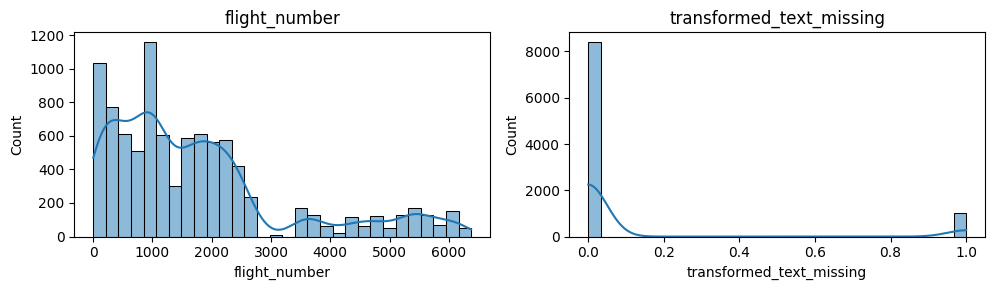

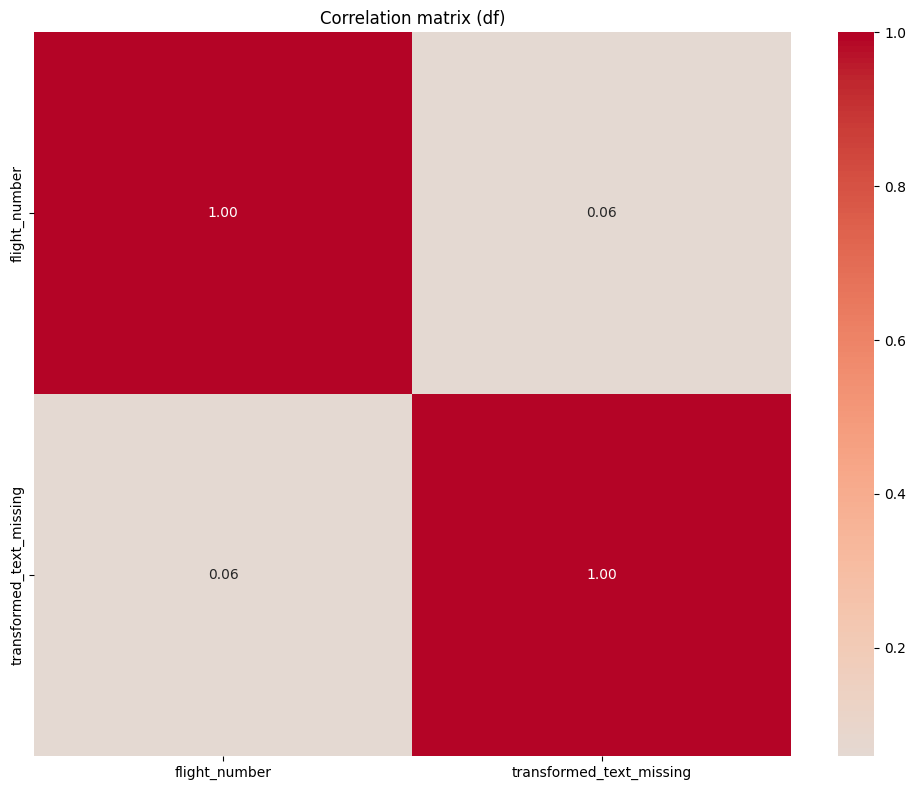

In [48]:
# DF: numeric histograms + correlation matrix (df)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

if 'df' not in globals():
    print('df is not in memory. Run earlier cells to load df before running this cell.')
else:
    num_df = df.select_dtypes(include=[np.number]).copy()
    if num_df.shape[1] == 0:
        print('No numeric columns found in df to plot.')
    else:
        display(num_df.describe().T)
        # Histograms (compact grid)
        ncols = 3
        nplots = num_df.shape[1]
        nrows = int(np.ceil(nplots / ncols))
        plt.figure(figsize=(5 * ncols, 3 * nrows))
        for i, col in enumerate(num_df.columns):
            plt.subplot(nrows, ncols, i + 1)
            sns.histplot(num_df[col].dropna(), kde=True, bins=30)
            plt.title(col)
        plt.tight_layout()
        plt.show()

        # Correlation matrix and heatmap
        corr = num_df.corr()
        plt.figure(figsize=(10, 8))
        sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
        plt.title('Correlation matrix (df)')
        plt.tight_layout()
        plt.show()

,count,mean,std,min,25%,50%,75%,max
num_passengers,49283.0,1.590204,1.016540,1.00,1.00,1.00,2.00,9.0
purchase_lead,49283.0,81.604772,81.207474,0.00,21.00,51.00,115.00,287.0
length_of_stay,49283.0,20.710306,21.818939,0.00,5.00,17.00,28.00,84.0
flight_hour,49283.0,9.070613,5.413007,0.00,5.00,9.00,13.00,23.0
wants_extra_baggage,49283.0,0.668222,0.470856,0.00,0.00,1.00,1.00,1.0
wants_preferred_seat,49283.0,0.295639,0.456334,0.00,0.00,0.00,1.00,1.0
wants_in_flight_meals,49283.0,0.426638,0.494594,0.00,0.00,0.00,1.00,1.0
flight_duration,49283.0,7.279937,1.496381,4.67,5.62,7.57,8.83,9.5
booking_complete,49283.0,0.149991,0.357066,0.00,0.00,0.00,0.00,1.0


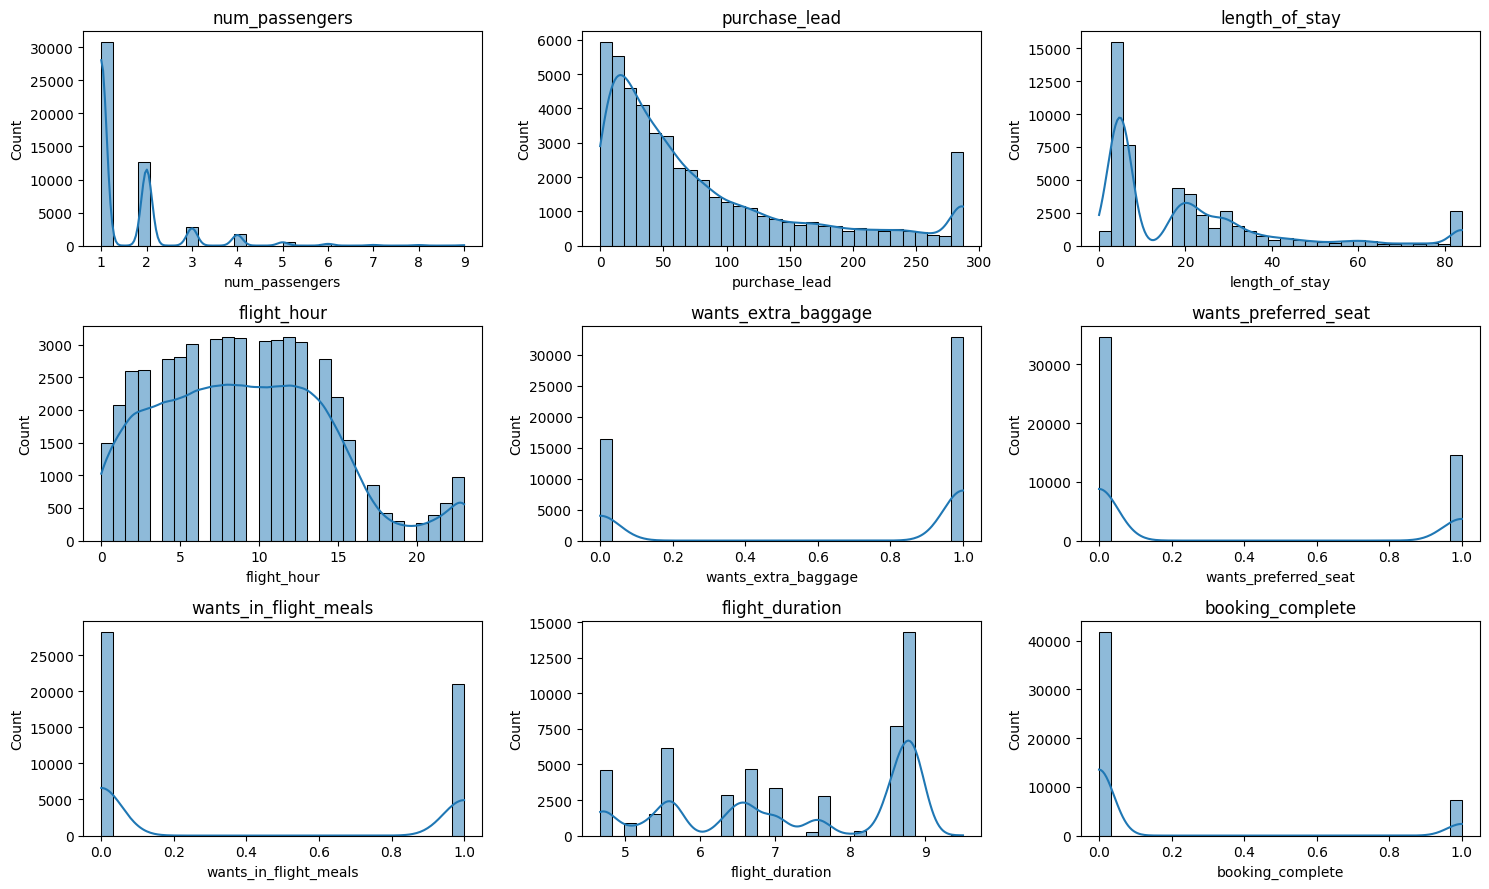

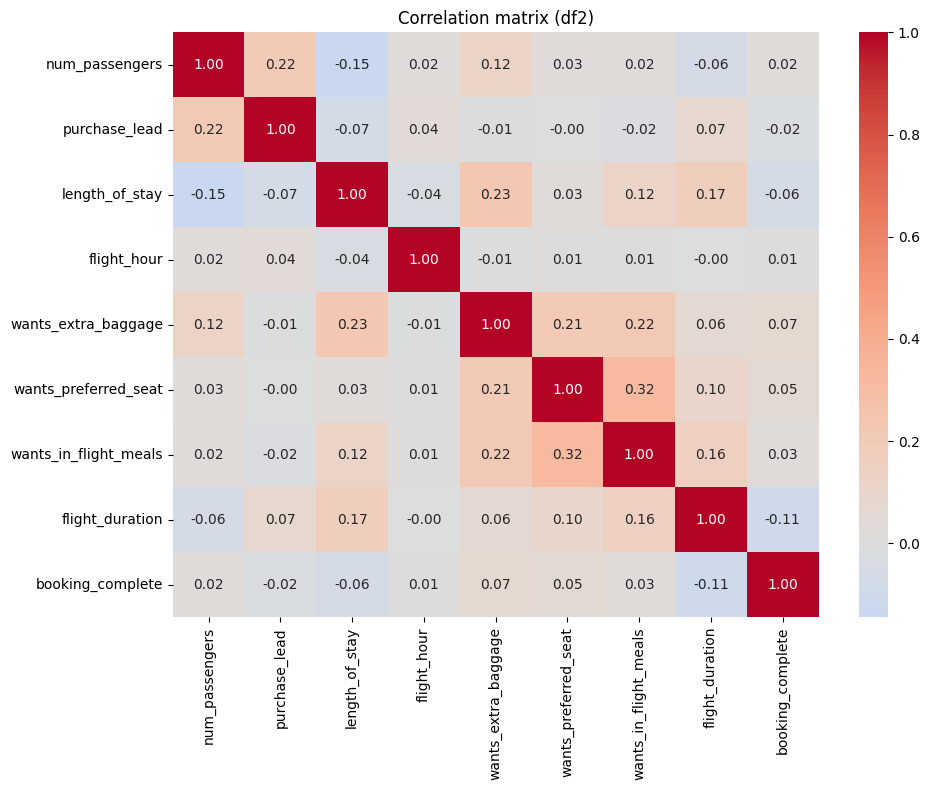

In [49]:
# DF2: numeric histograms + correlation matrix (df2)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

if 'df2' not in globals():
    print('df2 is not in memory. Run earlier cells to load df2 before running this cell.')
else:
    num_df2 = df2.select_dtypes(include=[np.number]).copy()
    if num_df2.shape[1] == 0:
        print('No numeric columns found in df2 to plot.')
    else:
        display(num_df2.describe().T)
        ncols = 3
        nplots = num_df2.shape[1]
        nrows = int(np.ceil(nplots / ncols))
        plt.figure(figsize=(5 * ncols, 3 * nrows))
        for i, col in enumerate(num_df2.columns):
            plt.subplot(nrows, ncols, i + 1)
            sns.histplot(num_df2[col].dropna(), kde=True, bins=30)
            plt.title(col)
        plt.tight_layout()
        plt.show()

        corr2 = num_df2.corr()
        plt.figure(figsize=(10, 8))
        sns.heatmap(corr2, annot=True, fmt='.2f', cmap='coolwarm', center=0)
        plt.title('Correlation matrix (df2)')
        plt.tight_layout()
        plt.show()

,count,mean,std,min,25%,50%,75%,max
flight_number,46974.0,1522.482267,1449.136988,2.0,476.0,1044.0,2054.0,6376.0
arrival_delay_minutes,46974.0,-1.698770,37.881533,-104.0,-19.0,-9.0,4.0,907.0
number_of_legs,46974.0,1.343573,0.502269,1.0,1.0,1.0,2.0,3.0
actual_flown_miles,46974.0,2481.779048,1865.368455,45.0,938.0,1846.0,3878.0,8440.0


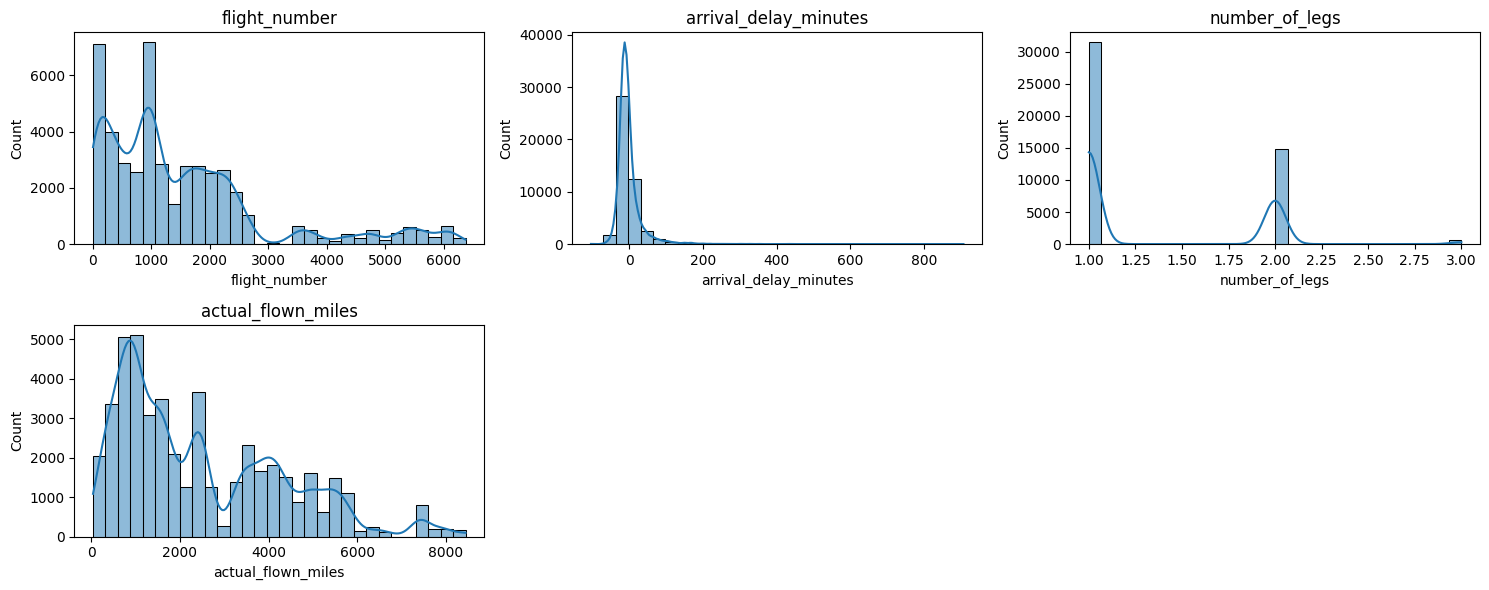

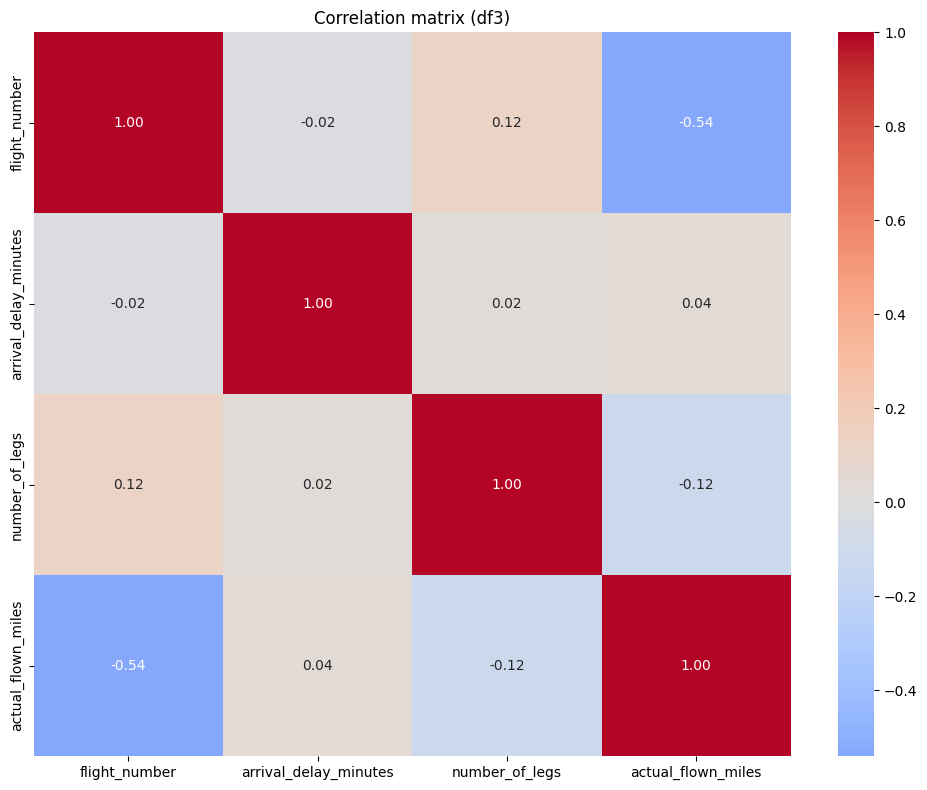

In [50]:
# DF3: numeric histograms + correlation matrix (df3)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

if 'df3' not in globals():
    print('df3 is not in memory. Run earlier cells to load df3 before running this cell.')
else:
    num_df3 = df3.select_dtypes(include=[np.number]).copy()
    if num_df3.shape[1] == 0:
        print('No numeric columns found in df3 to plot.')
    else:
        display(num_df3.describe().T)
        ncols = 3
        nplots = num_df3.shape[1]
        nrows = int(np.ceil(nplots / ncols))
        plt.figure(figsize=(5 * ncols, 3 * nrows))
        for i, col in enumerate(num_df3.columns):
            plt.subplot(nrows, ncols, i + 1)
            sns.histplot(num_df3[col].dropna(), kde=True, bins=30)
            plt.title(col)
        plt.tight_layout()
        plt.show()

        corr3 = num_df3.corr()
        plt.figure(figsize=(10, 8))
        sns.heatmap(corr3, annot=True, fmt='.2f', cmap='coolwarm', center=0)
        plt.title('Correlation matrix (df3)')
        plt.tight_layout()
        plt.show()

,count,mean,std,min,25%,50%,75%,max
Rating,2648.0,4.450906,3.125605,1.000000,1.000000,3.000000,7.000000,10.000000
Start_Latitude,2648.0,41.366815,19.310142,-37.666951,38.707751,51.154108,51.507446,65.011873
Start_Longitude,2648.0,-5.931798,50.365357,-123.182909,-2.245115,-0.182312,4.383210,151.208285
End_Latitude,2648.0,38.802021,20.967816,-37.814245,34.923609,48.853495,51.507446,64.145981
End_Longitude,2648.0,-4.902224,51.981791,-123.179234,-4.421637,-0.182312,10.393678,174.550610
flight_distance_km,2648.0,5477.144914,3755.961885,4.384010,1471.349888,5834.909168,8465.442202,18177.385903
has_layover,2648.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
route_length,2648.0,1.005665,0.075065,1.000000,1.000000,1.000000,1.000000,2.000000
review_length,2648.0,907.255665,593.045667,83.000000,487.000000,756.000000,1150.000000,3534.000000
word_count,2648.0,164.436556,109.622802,15.000000,87.000000,135.500000,207.000000,655.000000


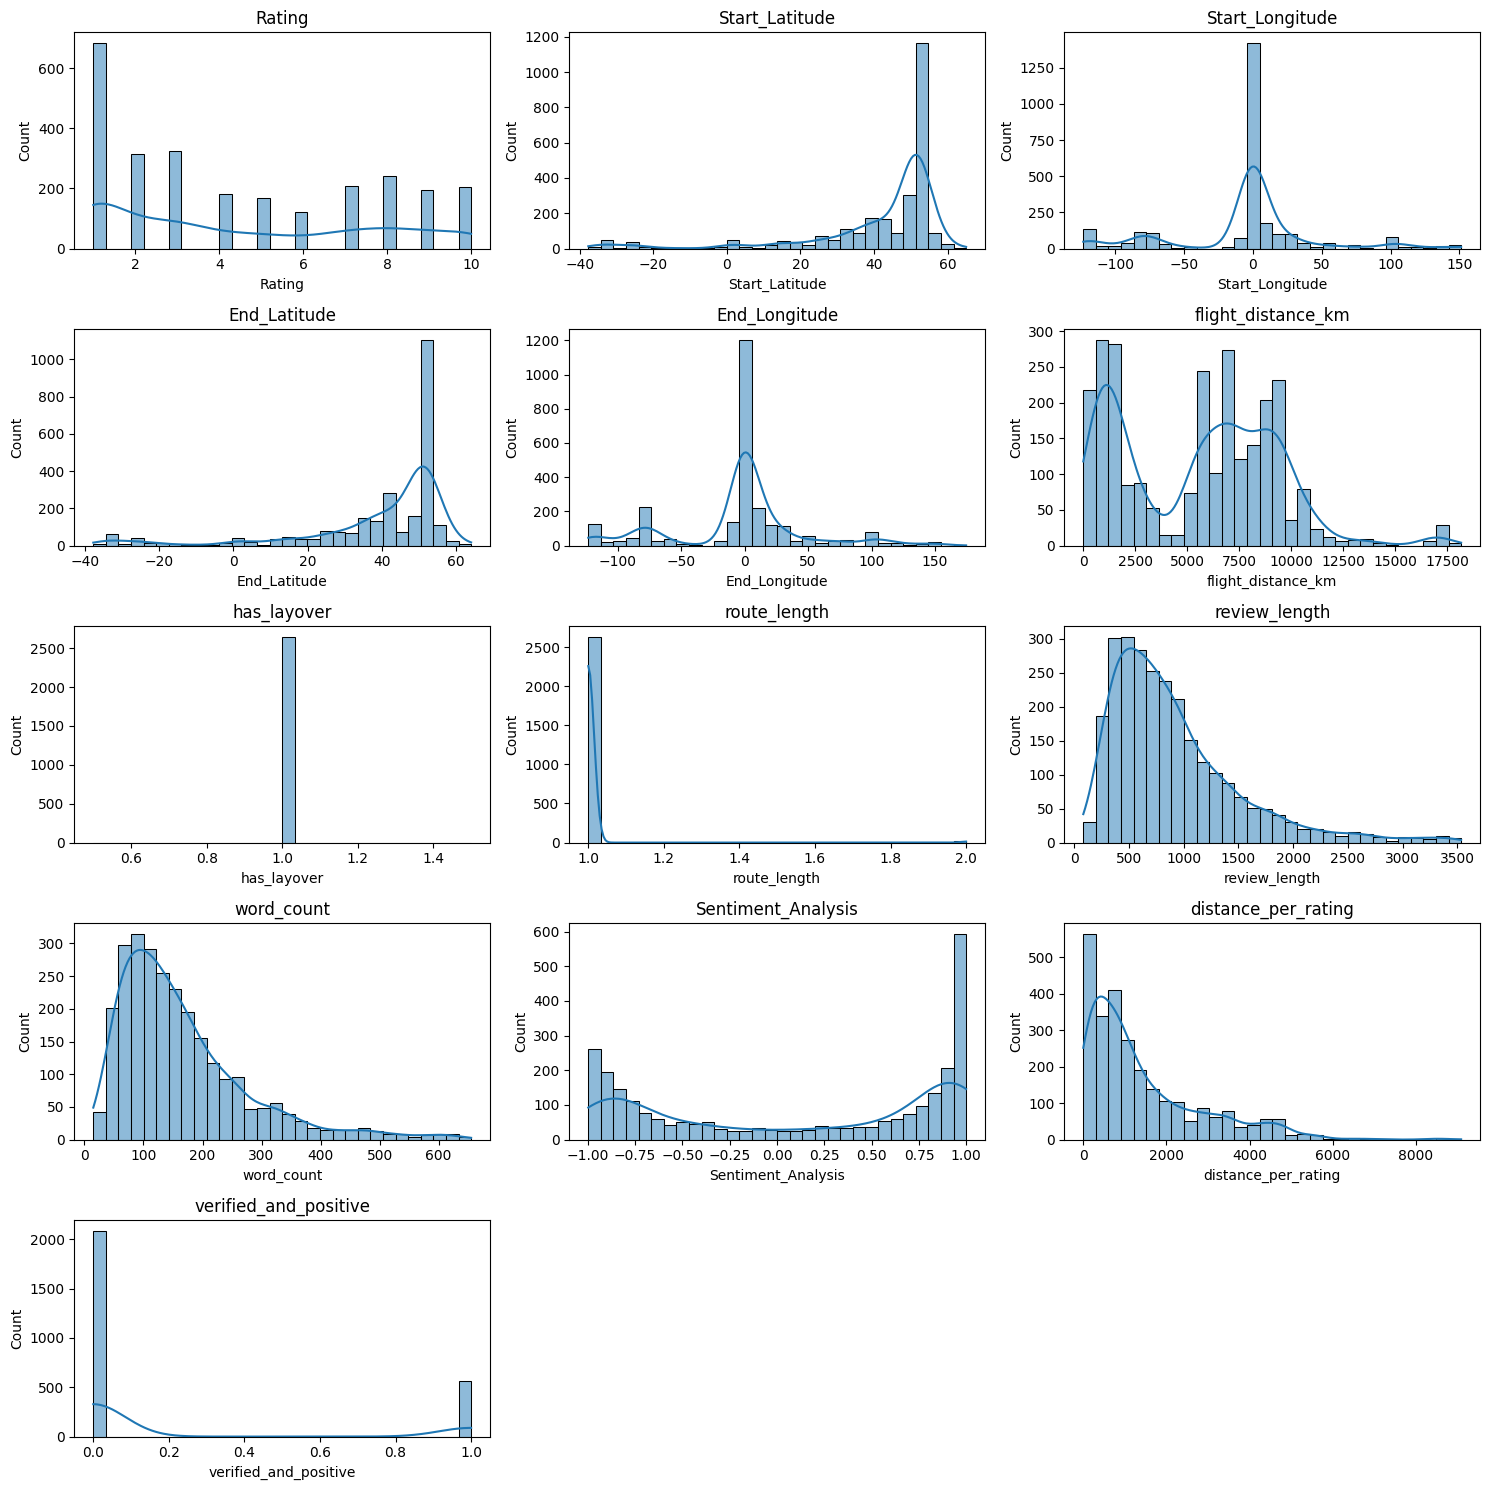

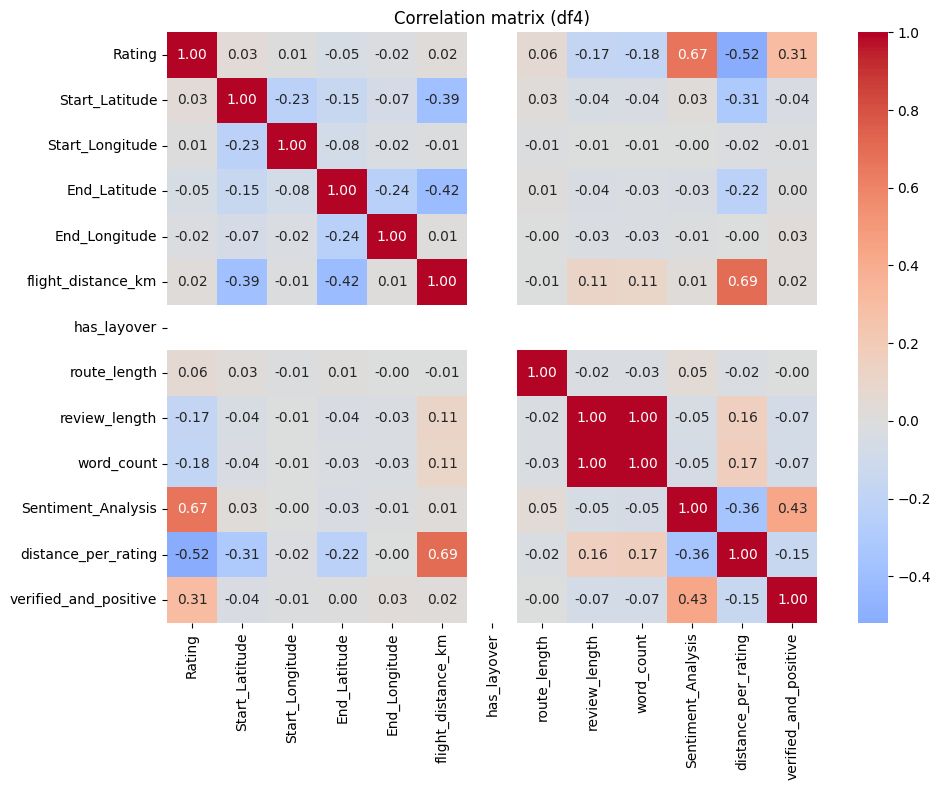

In [51]:
# DF4: numeric histograms + correlation matrix (df4)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

if 'df4' not in globals():
    print('df4 is not in memory. Run earlier cells to load df4 before running this cell.')
else:
    num_df4 = df4.select_dtypes(include=[np.number]).copy()
    if num_df4.shape[1] == 0:
        print('No numeric columns found in df4 to plot.')
    else:
        display(num_df4.describe().T)
        ncols = 3
        nplots = num_df4.shape[1]
        nrows = int(np.ceil(nplots / ncols))
        plt.figure(figsize=(5 * ncols, 3 * nrows))
        for i, col in enumerate(num_df4.columns):
            plt.subplot(nrows, ncols, i + 1)
            sns.histplot(num_df4[col].dropna(), kde=True, bins=30)
            plt.title(col)
        plt.tight_layout()
        plt.show()

        corr4 = num_df4.corr()
        plt.figure(figsize=(10, 8))
        sns.heatmap(corr4, annot=True, fmt='.2f', cmap='coolwarm', center=0)
        plt.title('Correlation matrix (df4)')
        plt.tight_layout()
        plt.show()

### ANSWERING THE QUESTIONS

/var/folders/5d/vpl0k2cx46db2_nt71krcf700000gp/T/ipykernel_1657/2534409584.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10.values, y=top10.index, palette='viridis')


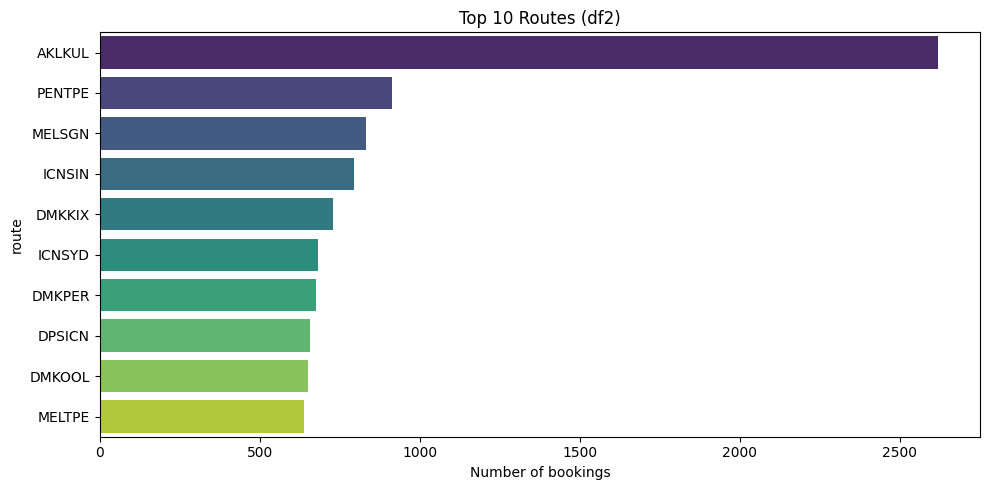

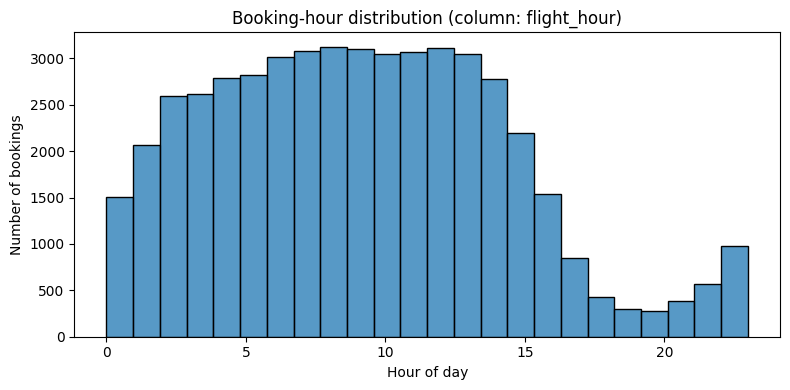

In [52]:
# APPENDED EDA: Top-10 routes & booking-hour distribution (uses df2)
import matplotlib.pyplot as plt
import seaborn as sns

if 'df2' not in globals():
    print('df2 is not in memory. Run the earlier df2 loading cells first.')
else:
    # Find a plausible route column in df2
    for cands in [['Route'], ['route'], ['RouteName', 'Route_Name'], ['origin_destination', 'Origin-Destination']]:
        route_col = next((c for c in cands if c in df2.columns), None)
        if route_col is not None:
            break
    else:
        route_col = None

    if route_col is None:
        print('No route-like column found in df2 — top-10 routes skipped.')
    else:
        top10 = df2[route_col].value_counts().nlargest(10)
        plt.figure(figsize=(10, 5))
        sns.barplot(x=top10.values, y=top10.index, palette='viridis')
        plt.title('Top 10 Routes (df2)')
        plt.xlabel('Number of bookings')
        plt.ylabel(route_col)
        plt.tight_layout()
        plt.show()

    # Booking-hour distribution — look for flight_hour, booking_hour, purchase_time_hour
    hour_candidates = ['flight_hour', 'booking_hour', 'purchase_hour', 'hour']
    hour_col = next((h for h in hour_candidates if h in df2.columns), None)
    if hour_col is None:
        print('No booking-hour-like column found in df2 — booking-hour distribution skipped.')
    else:
        plt.figure(figsize=(8, 4))
        sns.histplot(df2[hour_col].dropna().astype(int), bins=24, kde=False)
        plt.title(f'Booking-hour distribution (column: {hour_col})')
        plt.xlabel('Hour of day')
        plt.ylabel('Number of bookings')
        plt.tight_layout()
        plt.show()

Detected columns — traveller: entity , class: cabin_code_desc , rating: score
Top 10 traveller-class combos by mean score


,mean,count
_traveller_class_combo,,
Domestic | United Premium Plus,3.295302,149
Latin | Business,3.156579,760
Domestic | Economy,2.948367,16288
Pacific | United Premium Plus,2.880952,84
Domestic | Business,2.879301,7324
Pacific | Business,2.844444,315
Latin | Economy,2.810424,1746
Latin | United Premium Plus,2.804878,41
Atlantic | Economy,2.762780,4460


Bottom 10 traveller-class combos by mean score


,mean,count
_traveller_class_combo,,
Domestic | Economy,2.948367,16288
Pacific | United Premium Plus,2.880952,84
Domestic | Business,2.879301,7324
Pacific | Business,2.844444,315
Latin | Economy,2.810424,1746
Latin | United Premium Plus,2.804878,41
Atlantic | Economy,2.762780,4460
Pacific | Economy,2.737828,534
Atlantic | United Premium Plus,2.722892,830


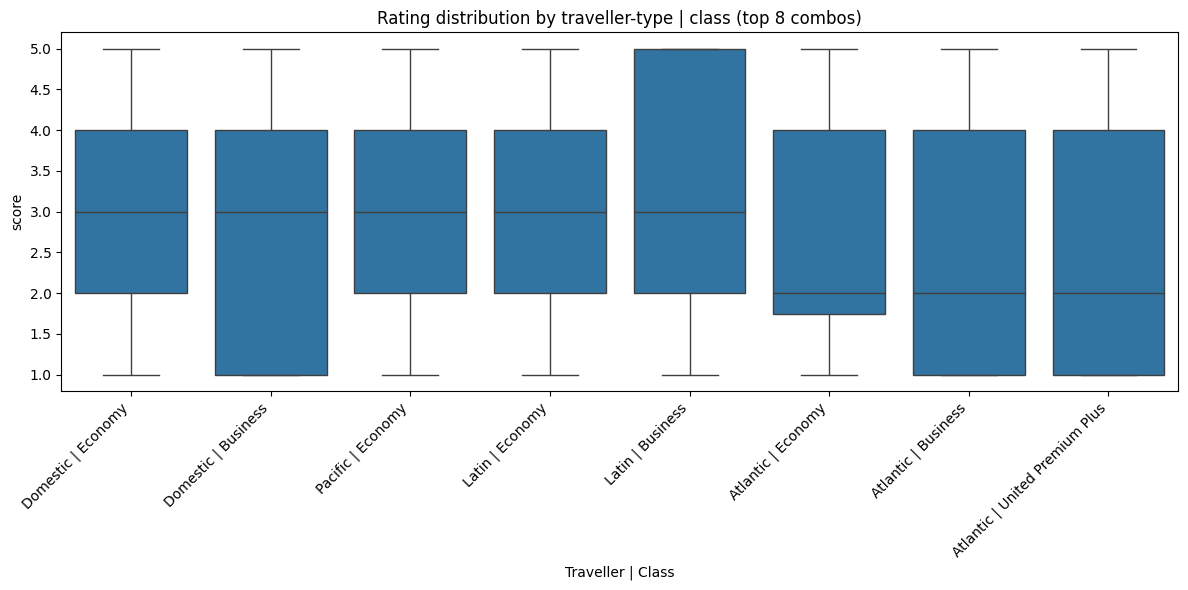

In [53]:
# APPENDED EDA (REVISED): Traveller type × class vs rating (uses df3) — robust column detection
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

if 'df3' not in globals():
    print('df3 is not in memory. Run the earlier df3 loading cells first.')
else:
    # Candidate column names extended to match what's actually in df3 (look for cabin_name/cabin_code_desc/entity etc.)
    traveller_candidates = ['traveller_type', 'traveler_type', 'traveller', 'customer_type', 'Passenger_Type', 'entity', 'passenger_type', 'passenger_category']
    class_candidates = ['class', 'cabin', 'cabin_class', 'cabinName', 'cabin_name', 'cabin_code_desc']
    rating_candidates = ['score', 'Score', 'rating', 'Rating']

    traveller_col = next((c for c in traveller_candidates if c in df3.columns), None)
    class_col = next((c for c in class_candidates if c in df3.columns), None)
    rating_col = next((c for c in rating_candidates if c in df3.columns), None)

    if rating_col is None:
        print('No rating-like column found in df3 (tried:', rating_candidates, '). Skipping this analysis.')
    else:
        # Inform what was detected
        print('Detected columns — traveller:', traveller_col, ', class:', class_col, ', rating:', rating_col)

        # Build a grouping key robustly: prefer traveller + class, else whichever exists, else use a placeholder 'ALL'
        if traveller_col is not None and class_col is not None:
            df3['_traveller_class_combo'] = df3[traveller_col].astype(str).fillna('') + ' | ' + df3[class_col].astype(str).fillna('')
        elif traveller_col is not None:
            df3['_traveller_class_combo'] = df3[traveller_col].astype(str).fillna('')
        elif class_col is not None:
            df3['_traveller_class_combo'] = df3[class_col].astype(str).fillna('')
        else:
            # no traveller/class info — create a single-group column so we can still compute global stats
            df3['_traveller_class_combo'] = 'ALL'

        # Ensure rating column is numeric for aggregation
        df3['_rating_numeric_tmp'] = pd.to_numeric(df3[rating_col], errors='coerce')

        # Compute mean rating per combo and show top/bottom (require at least 1 non-null value)
        combo_stats = df3.groupby('_traveller_class_combo')['_rating_numeric_tmp'].agg(['mean','count']).dropna().sort_values(['mean','count'], ascending=[False,False])
        print('Top 10 traveller-class combos by mean', rating_col)
        display(combo_stats.head(10))
        print('Bottom 10 traveller-class combos by mean', rating_col)
        display(combo_stats.tail(10))

        # Visual: boxplot of rating by top N combos (if many combos, focus on top by count)
        if combo_stats.shape[0] == 0:
            print('No valid combos with numeric ratings to plot.')
        else:
            top_combos = combo_stats.sort_values('count', ascending=False).head(8).index.tolist()
            plt.figure(figsize=(12,6))
            sns.boxplot(x='_traveller_class_combo', y='_rating_numeric_tmp', data=df3[df3['_traveller_class_combo'].isin(top_combos)])
            plt.xticks(rotation=45, ha='right')
            plt.xlabel('Traveller | Class')
            plt.ylabel(rating_col)
            plt.title(f'Rating distribution by traveller-type | class (top {len(top_combos)} combos)')
            plt.tight_layout()
            plt.show()

        # clean up temporary column(s) if desired (keeps _traveller_class_combo for inspection)
        try:
            del df3['_rating_numeric_tmp']
        except Exception:
            pass

Step 3: Model Training

Create 'is_satisfied' Column
This line of code creates a new binary column named is_satisfied in the df4 DataFrame.

df4['is_satisfied'] = np.where(df4['Rating'] >= 5, 1, 0)

Purpose:

The goal is to convert the numerical Rating column into a simple binary classification: "satisfied" (1) or "not satisfied" (0). This is a common step in preparing data for machine learning models or for simpler categorical analysis.

How it works:

It uses the np.where() function from the NumPy library, which works like a vectorized "if-then-else" statement:
Condition: df4['Rating'] >= 5
For every row in the DataFrame, it checks if the value in the 'Rating' column is greater than or equal to 5.
Value if True: 1
If the condition is met (the rating is 5, 6, or 7), it assigns the value 1 to this row in the new is_satisfied column.
Value if False: 0
If the condition is not met (the rating is less than 5), it assigns the value 0.

In [54]:
df4['is_satisfied'] = np.where(df4['Rating'] >= 5, 1, 0)

This code prepares the data for machine learning by defining the target variable y as the is_satisfied column and creating the feature matrix X by selecting a specific list of 19 input columns from the df4 DataFrame. It then groups these feature names into categorical, numerical, and text lists to organize them for future preprocessing.

The features were chosen to build a comprehensive model of customer satisfaction by capturing four distinct, yet related, dimensions of the user's experience:
Trip Context: What was the nature of the flight?

Geospatial Data: Where did the passenger travel?

Review Sentiment: What did the passenger say?

Engineered Features: What specific interactions between these factors are most predictive?

1. Trip Context Features (The "What")
These features define the core product and service level the passenger purchased and experienced.
Traveller_Type: Evidence: This is one of the strongest predictors. Business travelers (who may be less price-sensitive and value punctuality) have different expectations than 'Couple' or 'Family' travelers (who might prioritize comfort, in-flight entertainment, and service).

Class: Evidence: This directly correlates with service level (Economy, Business, First). Models consistently find that passengers in premium classes report higher satisfaction due to more space, better food, and more attentive service.

Route / Layover_Route: Evidence: Specific routes (e.g., long-haul international vs. short domestic) have different service standards. Layover_Route is particularly critical, as layovers are a major source of travel friction (delays, baggage transfers, stress). A non-null Layover_Route (or the has_layover feature) is a powerful indicator of potential dissatisfaction.

Verified: Evidence: This is a data quality feature. By using only "Verified" reviews (e.g., from a verified booking), the model is trained on authentic feedback, making its predictions more reliable by filtering out potential spam or unverified complaints.

2. Geospatial Features (The "Where")
This group of features provides the raw data to calculate the physical logistics of the journey.

Start_Latitude, Start_Longitude, End_Latitude, End_Longitude: 
Evidence: By themselves, these raw coordinates are not very useful to a model. Their purpose is almost certainly to be used in feature engineering.

flight_distance_km: 
Evidence: This is the result of engineering the coordinate features. Flight distance is a key variable. Very short flights and ultra-long-haul flights have different satisfaction drivers. This feature allows the model to learn, for example, that while a 30-minute delay is frustrating on a 1-hour flight, it's negligible on a 14-hour one.

3. Review Sentiment Features (The "What")
This group directly quantifies the customer's explicitly stated opinion.

Sentiment_Analysis: Evidence: This is a numerical score (e.g., -0.8 to +0.8) from a Natural Language Processing (NLP) model. It provides a granular measure of how positive or negative the review text is. A score of 0.1 ("slightly positive") is treated differently than 0.9 ("overwhelmingly positive").

Sentiment_Label: Evidence: This is the categorical version of the sentiment score (e.g., 'Positive', 'Negative', 'Neutral'). It provides a clear, strong signal for classification and is often the primary text-based predictor.

word_count: Evidence: A standard NLP feature. It's a proxy for user engagement or passion. Very low word counts (e.g., "Great flight.") are almost always positive. Conversely, extremely long reviews are often associated with detailed complaints and negative sentiment.

4. Engineered Features (The "Interactions")
These are the most sophisticated features. They combine variables from the other groups to test specific, high-value hypotheses.

has_layover: Evidence: This binary feature (1 or 0) is engineered from Layover_Route. It simplifies the "Route" information into a single, powerful "yes/no" question: "Did this passenger experience the friction of a layover?" This is often more predictive than the route itself.

distance_per_rating: Evidence: This is an advanced interaction feature. By dividing distance by rating, it likely seeks to penalize dissatisfaction on long flights more heavily. For example, a low rating on a long flight would result in a very high value for this feature, flagging it as a significant service failure.

verified_and_positive: Evidence: This feature combines data quality (Verified) with sentiment (Sentiment_Label). It isolates the "trusted positive" reviews. This can help the model distinguish between genuine, verified satisfaction and potentially unverified or low-effort positive feedback.

route_length: Evidence: This likely represents the number of legs in a journey (e.g., 1 for direct, 2 for one layover). Like has_layover, it quantifies the complexity and hassle of the trip, which is a common predictor of dissatisfaction.

In [55]:
print(f"Core_Merged_Data.csv loaded successfully. Initial rows: {df4.shape[0]}")
# --- 2. Define Target Variable (y) ---
y = df4['is_satisfied'].astype(int)

# --- 3. Final Feature Selection Based on Requirements ---
feature_columns = [
        'Route',
        'Verified',
        'Traveller_Type',
        'Class',
        'Start_Location',
        'End_Location',
        'Layover_Route',
        'Start_Latitude',
        'Start_Longitude',
        'End_Latitude',
        'End_Longitude',
        'Sentiment_Analysis',
        'flight_distance_km',
        'has_layover',
        'route_length',
        'word_count',
        'distance_per_rating',
        'verified_and_positive',
        'Sentiment_Label'
    ]

# Create the Feature Matrix X
X = df4[feature_columns].copy()

# --- 5. Separate Feature Types for Preprocessing ---

categorical_features = [
        'Route',
        'Verified',
        'Traveller_Type',
        'Class',
        'Start_Location',
        'End_Location',
        'Layover_Route',
        'Sentiment_Label'
    ]

# Numerical Features (need Scaling/Normalization)
numerical_features = [
        'Start_Latitude',
        'Start_Longitude',
        'End_Latitude',
        'End_Longitude',
        'Sentiment_Analysis',
        'flight_distance_km',
        'has_layover',
        'route_length',
        'word_count',
        'distance_per_rating',
        'verified_and_positive'
    ]

# Text Features (need TF-IDF Vectorization or similar)
text_features = [
        'Passanger_Name',
        'Route',
        'Review_title',
        'Review_content',
        'Layover_Route',
        'Start_Address',
        'End_Address'
    ]


print(f"\n--- Final X and y Shapes ---")
print(f"Feature Matrix (X) shape: {X.shape}")
print(f"Target Vector (y) shape: {y.shape}")

Core_Merged_Data.csv loaded successfully. Initial rows: 2648

--- Final X and y Shapes ---
Feature Matrix (X) shape: (2648, 19)
Target Vector (y) shape: (2648,)


This line calculates the percentage distribution of the classes (e.g., 0 and 1) in your target variable y.

1- y.value_counts(): Counts the number of times each unique value (e.g., 1s and 0s) appears.

2- normalize=True: Converts these raw counts into proportions or percentages (e.g., 0.55 and 0.45).

3- * 100: Scales these proportions by 100 to make them easier to read (e.g., 55.0 and 45.0).

The result shows what percentage of your data belongs to the "satisfied" class versus the "not satisfied" class, which is critical for checking class imbalance.

In [56]:
y.value_counts(normalize=True) * 100

is_satisfied
0    56.986405
1    43.013595
Name: proportion, dtype: float64

This code preprocesses the X feature matrix by first defining a ColumnTransformer that specifies two rules: 

(1) apply OneHotEncoder to all categorical_features to convert text categories into new binary (0/1) columns

(2) let all numerical_features pass through unchanged. Second, it applies this transformer to the X data using .fit_transform(), creating a NumPy array X_encoded containing only numbers. 

Finally, it retrieves the new column names generated by the encoder (e.g., Class_Economy), combines them with the original numerical column names, and uses them to create a new, fully-preprocessed DataFrame X_encoded_df ready for model training.


One-Hot Encoding (OHE) is crucial because it converts non-numeric categorical data (like 'Economy' or 'Business') into a numerical 0/1 format that machine learning models can read. Its main benefit is that it avoids creating a false ordinal relationship, unlike other methods that might incorrectly teach a model that 'First' class (e.g., encoded as 2) is "twice" as valuable as 'Business' class (e.g., encoded as 1). This process changes the data's values to 0s and 1s, fixes the range of these new columns to [0, 1], and preserves the original data's distribution (now seen as the mean of each new column), but it significantly increases the total number of columns (dimensionality) in your dataset.

In [57]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

# Define the column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
        ('num', 'passthrough', numerical_features)
    ]
)

# Fit and transform the data
X_encoded = preprocessor.fit_transform(X)

# Retrieve the encoded feature names
encoded_feature_names = (
    preprocessor.named_transformers_['cat']
    .get_feature_names_out(categorical_features)
)

# Combine all column names (categorical + numerical)
all_feature_names = list(encoded_feature_names) + numerical_features

# Create a DataFrame for the encoded features
X_encoded_df = pd.DataFrame(X_encoded, columns=all_feature_names)


print("Encoded feature matrix shape:", X_encoded_df.shape)
X_encoded_df.head()

Encoded feature matrix shape: (2648, 2216)


,Route_ Bridgetown to Gatwick,Route_ London Heathrow to Madrid,Route_ABV to LHR,Route_ACC to LHR,Route_ACC to ZRH via LHR,Route_AGP to LGW,Route_AMS to BKK via LHR,Route_AMS to GRU via LHR,Route_AMS to LGW,Route_AMS to LHR,...,Start_Longitude,End_Latitude,End_Longitude,Sentiment_Analysis,flight_distance_km,has_layover,route_length,word_count,distance_per_rating,verified_and_positive
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-90.078213,51.507446,-0.127765,-0.7990,7444.562362,1.0,1.0,136.0,3722.281181,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.127765,31.951569,35.923963,0.0219,3640.047228,1.0,1.0,320.0,1820.023614,1.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.458780,37.034399,27.430651,-0.7096,2713.229893,1.0,1.0,53.0,904.409964,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,35.923963,51.507446,-0.127765,-0.5849,3640.047228,1.0,1.0,48.0,728.009446,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-81.229153,38.974390,1.419746,0.9789,6661.470661,1.0,1.0,182.0,832.683833,1.0


This code block uses StandardScaler to standardize the X_encoded_df DataFrame, which is a crucial step for many machine learning models. 

First, it initializes the StandardScaler object. 

Second, it applies the .fit_transform() method, which calculates the mean and standard deviation for each feature column and then rescales all values so that each feature has a mean of 0 and a standard deviation of 1. 

Finally, it converts the resulting NumPy array (X_scaled) back into a Pandas DataFrame (X_scaled_df), preserving the original column names from X_encoded_df for continued analysis and model training.


StandardScaler is crucial for standardizing numerical features to a common scale, which is essential for models like Logistic Regression, KNN, and SVMs. It works by subtracting the mean and dividing by the standard deviation for each feature column independently. This transformation changes the data's distribution to have a mean of 0 and a standard deviation of 1. This is vital because it prevents features with large ranges (like flight_distance_km) from disproportionately influencing the model's outcome compared to features with small ranges (like Sentiment_Analysis), leading to faster and more reliable model training.

In [58]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()


# Fit and transform the encoded feature matrix
X_scaled = scaler.fit_transform(X_encoded_df)

# Convert back to a DataFrame with the same column names
X_scaled_df = pd.DataFrame(X_scaled, columns=X_encoded_df.columns)

print("Scaled feature matrix shape:", X_scaled_df.shape)
X_scaled_df.head()

Scaled feature matrix shape: (2648, 2216)


,Route_ Bridgetown to Gatwick,Route_ London Heathrow to Madrid,Route_ABV to LHR,Route_ACC to LHR,Route_ACC to ZRH via LHR,Route_AGP to LGW,Route_AMS to BKK via LHR,Route_AMS to GRU via LHR,Route_AMS to LGW,Route_AMS to LHR,...,Start_Longitude,End_Latitude,End_Longitude,Sentiment_Analysis,flight_distance_km,has_layover,route_length,word_count,distance_per_rating,verified_and_positive
0,-0.019437,-0.019437,-0.019437,-0.019437,-0.019437,-0.027493,-0.019437,-0.019437,-0.027493,-0.043495,...,-1.671036,0.606063,0.091866,-1.170008,0.523911,0.0,-0.075478,-0.259453,1.660029,-0.518466
1,-0.019437,-0.019437,-0.019437,-0.019437,-0.019437,-0.027493,-0.019437,-0.019437,-0.027493,-0.043495,...,0.115260,-0.326774,0.785542,-0.119953,-0.489207,0.0,-0.075478,1.419347,0.289426,1.928767
2,-0.019437,-0.019437,-0.019437,-0.019437,-0.019437,-0.027493,-0.019437,-0.019437,-0.027493,-0.043495,...,0.108687,-0.084318,0.622121,-1.055652,-0.736013,0.0,-0.075478,-1.016737,-0.370286,-0.518466
3,-0.019437,-0.019437,-0.019437,-0.019437,-0.019437,-0.027493,-0.019437,-0.019437,-0.027493,-0.043495,...,0.831200,0.606063,0.091866,-0.896141,-0.489207,0.0,-0.075478,-1.062357,-0.497385,-0.518466
4,-0.019437,-0.019437,-0.019437,-0.019437,-0.019437,-0.027493,-0.019437,-0.019437,-0.027493,-0.043495,...,-1.495305,0.008222,0.121642,1.104194,0.315378,0.0,-0.075478,0.160247,-0.421966,1.928767


This code block 

first splits the scaled data (X_scaled_df) and target (y) into 80% training and 20% testing sets using train_test_split, using stratify=y to ensure both sets have the same percentage of positive/negative samples. 

Second, it initializes and trains a RandomForestClassifier model on the newly created training data (X_train, y_train). 

Third, it extracts the .feature_importances_ from the trained model, which measures how much each feature contributed to the model's decisions, and saves them in a sorted Pandas Series. 

Finally, it uses seaborn to create and display a horizontal bar chart visualizing the Top 20 most important features, showing which factors were most predictive.

X_train shape: (2118, 2216)
X_test shape: (530, 2216)
y_train shape: (2118,)
y_test shape: (530,)


/var/folders/5d/vpl0k2cx46db2_nt71krcf700000gp/T/ipykernel_1657/3422447505.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.head(20), y=importances.head(20).index, palette="viridis")


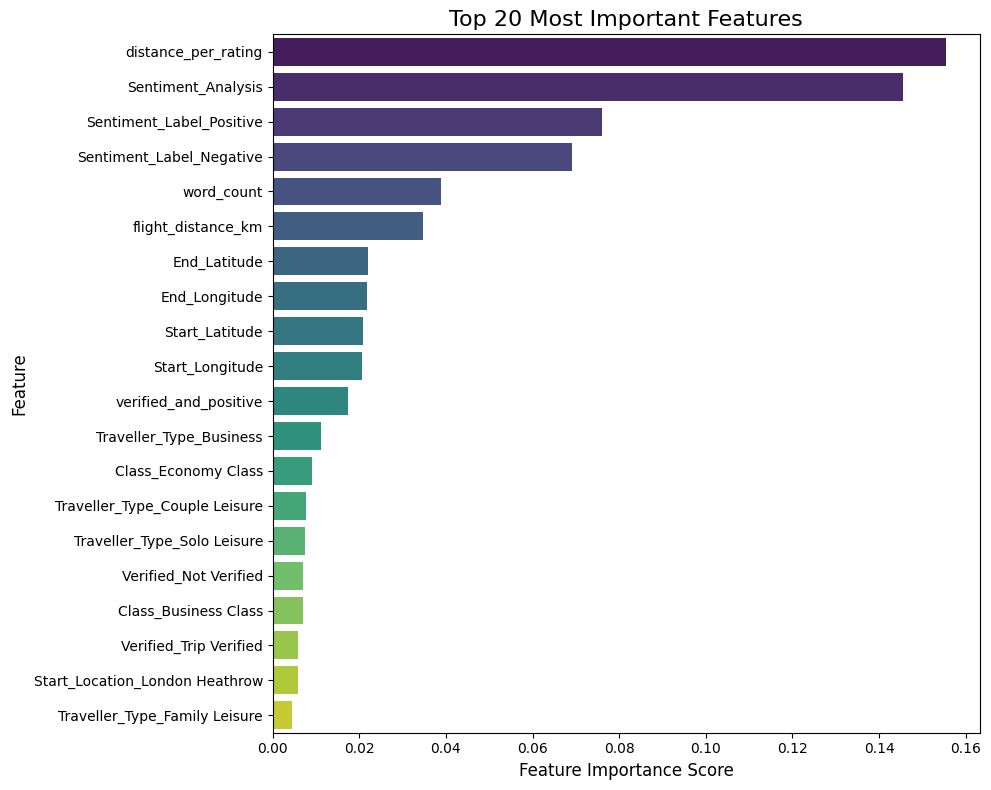

In [59]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Split the data (80% train, 20% test is standard)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_df, y, test_size=0.2, random_state=42, stratify=y
)

# Check shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Get feature importances
importances = pd.Series(rf.feature_importances_, index=X_scaled_df.columns)
importances = importances.sort_values(ascending=False)

# Plot top 20
plt.figure(figsize=(10, 8))
sns.barplot(x=importances.head(20), y=importances.head(20).index, palette="viridis")
plt.title("Top 20 Most Important Features", fontsize=16)
plt.xlabel("Feature Importance Score", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.tight_layout()
plt.show()

In [60]:
important_features = importances[importances > 0.001].index
X_reduced = X_scaled_df[important_features]

print(f"Reduced from {X_scaled.shape[1]} → {X_reduced.shape[1]} features.")

Reduced from 2216 → 42 features.


This code block is a comprehensive model comparison and hyperparameter tuning pipeline. Its goal is to find the best-performing machine learning model for the is_satisfied prediction task by systematically training, tuning, and evaluating six different algorithms.

Here is a step-by-step breakdown:

1. Model & Hyperparameter Setup
models Dictionary:  define six different classifiers to test: LogisticRegression, KNeighborsClassifier (KNN), DecisionTree, RandomForest, CatBoost, and GaussianNB (Naive Bayes).
param_grids Dictionary: For the models that benefit from tuning,  define a "search space" of hyperparameters. For example, for RandomForest,  test different numbers of trees (n_estimators) and tree depths (max_depth).
Setup:  initialize an empty dictionary best_models to store the winning (best-tuned) version of each model and a metrics dictionary to store their final performance scores.
StratifiedKFold:  define a 5-fold cross-validation strategy. Stratified is crucial for classification—it ensures that each of the 5 "folds" (or splits) of your training data has the same percentage of "satisfied" vs. "not satisfied" samples as the whole dataset.

2. Model Training and Tuning Loop
This is the core of the script. It loops through each model defined in your models dictionary.
Pipeline Creation: For each model, it creates an sklearn Pipeline.
If-Statement: The code correctly identifies that models like Logistic Regression and KNN are sensitive to the scale of the data. For them, it builds a pipeline that first runs StandardScaler (which you already did, but this ensures it's done correctly within the cross-validation) and then runs the classifier (clf).
Else-Statement: For tree-based models (Decision Tree, Random Forest, CatBoost), which are not sensitive to feature scale, it builds a simpler pipeline with just the classifier.
Hyperparameter Tuning:
It checks if a param_grids entry exists for the model.
If Yes (e.g., for CatBoost): It uses RandomizedSearchCV to automatically test 5 (n_iter=5) different combinations of the hyperparameters defined in your grid. It uses the 5-fold cross-validation (cv=cv) and ranks the combinations based on the f1_weighted score. The best-performing model is stored. n_jobs=-1 tells it to use all available CPU cores to speed this up.
If No (e.g., for Naive Bayes): It simply trains the model on the entire training set.
Evaluation: Once the best version of a model is found, it's used to make predictions on the unseen X_test data. It then calculates four key metrics (Accuracy, Precision, Recall, F1 Score) and stores them in the metrics dictionary.

3. Performance Visualization
DataFrame Creation: All the collected scores are converted into a Pandas DataFrame (metrics_df).
Plotting: The DataFrame is "melted" into a format suitable for seaborn. This allows you to plot a single bar chart that groups all four metrics (Accuracy, Precision, etc.) side-by-side for each of the six models, giving you a clear visual comparison of which model performed best overall.


Our Chosen Model: CatBoost
 CatBoost was our best-performing model, here's an explanation of what it is, its strengths, and its weaknesses.

CatBoost (Categorical Boosting) is an advanced, high-performance gradient boosting algorithm, similar to its famous cousins XGBoost and LightGBM. A gradient boosting model works by building trees sequentially: the first tree makes a prediction, the second tree tries to correct the errors of the first tree, the third corrects the errors of the first two, and so on.

Strengths

Best-in-Class Categorical Feature Handling: This is its main advantage. You do not need to One-Hot Encode (OHE) or label-encode your categorical data. You can pass the raw categorical features (like 'Route' or 'Class') directly to the model. CatBoost uses a unique and highly effective technique called Ordered Target Encoding, which is generally more accurate than OHE and avoids the "curse of dimensionality" (where OHE creates hundreds of new columns).

High Accuracy: CatBoost often produces state-of-the-art results with minimal hyperparameter tuning. Its use of "oblivious" or "symmetric" trees (where all nodes at the same level test the same feature) acts as a strong form of regularization, making it highly resistant to overfitting.

Robustness: It's generally less sensitive to hyperparameter choices than other boosting models. The default parameters often yield a very strong baseline.

Excellent GPU Support: It features a fast and efficient training implementation on GPUs.

Weaknesses & Limitations

CPU Training Speed: While very fast, it can sometimes be slower on CPUs than its main competitor, LightGBM, especially on datasets with many numerical features. Its advanced categorical data processing, while a strength, adds computational overhead.

Memory Usage: It can be more memory-intensive than LightGBM.

Symmetric Trees: The "symmetric tree" structure that prevents overfitting can also be a limitation. It's less flexible than the "leaf-wise" growth used by LightGBM, which can sometimes find more complex patterns (at the risk of overfitting).

CatBoost Hyperparameters & Performance
Hyperparameter Configuration (from our code)
We correctly identified the three most important hyperparameters to tune:
clf__iterations: This is simply the number of trees to build (equivalent to n_estimators in RandomForest). More trees are generally better but will take longer to train and can eventually overfit.
clf__depth: This controls the maximum depth of each tree. Deeper trees (e.g., 8-10) can capture more complex interactions, but shallower trees (e.g., 4-6) train faster and are less likely to overfit.
clf__learning_rate: This is the "step size" for each new tree. A small learning rate (e.g., 0.01) means the model learns slowly and cautiously, usually requiring more iterations but often resulting in a more accurate final model.

Training Performance & Speed
Compared to sklearn models (Logistic Regression, Decision Tree): CatBoost will be significantly slower. It is sequentially building hundreds of trees, which is far more complex than fitting a single decision tree or solving a linear equation (Logistic Regression).

Compared to RandomForest: It will often be slower. RandomForest builds all its trees in parallel (independently). CatBoost builds its trees sequentially (one after another), so it cannot be parallelized in the same way.

Compared to other Boosting Models: This is the key race. It is often faster than XGBoost on GPUs but slower than LightGBM on CPUs.
A Critical Note on Your Code's CatBoost Implementation


🔍 Tuning Logistic Regression...

🔍 Tuning KNN...

🔍 Tuning Decision Tree...

🔍 Tuning Random Forest...

🔍 Tuning CatBoost...

🔍 Tuning Naive Bayes...


/var/folders/5d/vpl0k2cx46db2_nt71krcf700000gp/T/ipykernel_1657/2677080329.py:117: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/zeyad_personal/Documents/GitHub/Team-50-Airline/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


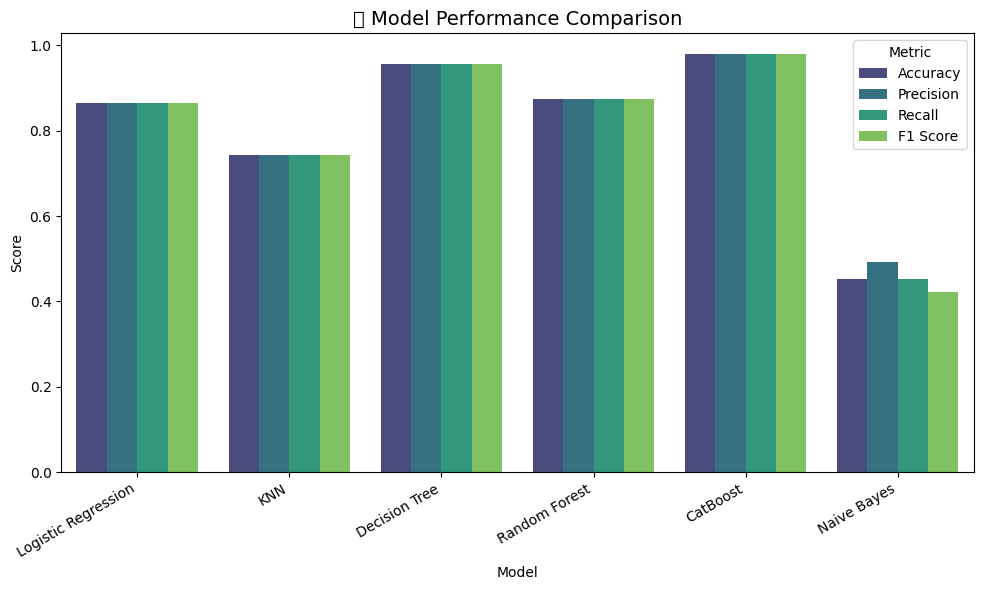

In [61]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------------------------
# 1️⃣ Define Models and Parameter Grids
# -----------------------------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42),
    "Naive Bayes": GaussianNB()
}

param_grids = {
    "Logistic Regression": {
        "clf__C": [0.01, 0.1, 1, 10],
        "clf__class_weight": [None, "balanced"]
    },
    "KNN": {
        "clf__n_neighbors": [3, 5, 7, 11],
        "clf__weights": ["uniform", "distance"]
    },
    "Decision Tree": {
        "clf__max_depth": [5, 10, 20, None],
        "clf__min_samples_split": [2, 5, 10]
    },
    "Random Forest": {
        "clf__n_estimators": [100, 200, 300],
        "clf__max_depth": [10, 20, None],
        "clf__min_samples_split": [2, 5, 10]
    },
    "CatBoost": {
        "clf__iterations": [200, 300],
        "clf__depth": [4, 6, 8],
        "clf__learning_rate": [0.01, 0.05, 0.1]
    }
}

best_models = {}
metrics = {"Model": [], "Accuracy": [], "Precision": [], "Recall": [], "F1 Score": []}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# -----------------------------------------------
# 2️⃣ Training + Hyperparameter Tuning
# -----------------------------------------------
for name, model in models.items():
    print(f"\n🔍 Tuning {name}...")

    # Pipeline for scaling (only for numeric-based models)
    if name in ["Logistic Regression", "KNN", "SVM"]:
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", model)
        ])
    else:
        pipe = Pipeline([("clf", model)])

    if param_grids.get(name):
        search = RandomizedSearchCV(
            pipe,
            param_distributions=param_grids[name],
            n_iter=5,
            scoring='f1_weighted',
            cv=cv,
            random_state=42,
            n_jobs=-1
        )
        search.fit(X_train, y_train)
        best_models[name] = search.best_estimator_
    else:
        pipe.fit(X_train, y_train)
        best_models[name] = pipe

    # Evaluate on test set
    y_pred = best_models[name].predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')


    metrics["Model"].append(name)
    metrics["Accuracy"].append(acc)
    metrics["Precision"].append(prec)
    metrics["Recall"].append(rec)
    metrics["F1 Score"].append(f1)

# -----------------------------------------------
# 3️⃣ Visualization of All Model Metrics
# -----------------------------------------------
metrics_df = pd.DataFrame(metrics)
metrics_melted = metrics_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(data=metrics_melted, x='Model', y='Score', hue='Metric', palette='viridis')
plt.xticks(rotation=30, ha='right')
plt.title('📊 Model Performance Comparison', fontsize=14)
plt.xlabel('Model')
plt.ylabel('Score')
plt.legend(title='Metric')
plt.tight_layout()
plt.show()


This code block is for displaying the final results of your model comparison. The print() function first outputs a clear title, "📋 Performance Summary:", to the console. Immediately after, the display() function (used in environments like Jupyter) renders the entire metrics_df DataFrame as a formatted table. By calling .round(3), it ensures all the performance metrics (Accuracy, Precision, etc.) stored in the DataFrame are rounded to three decimal places, making the final report clean and easy to read.

In [62]:
print("\n📋 Performance Summary:")
display(metrics_df.round(3))


📋 Performance Summary:


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.864,0.865,0.864,0.864
1,KNN,0.743,0.742,0.743,0.742
2,Decision Tree,0.957,0.957,0.957,0.957
3,Random Forest,0.874,0.874,0.874,0.874
4,CatBoost,0.979,0.979,0.979,0.979
5,Naive Bayes,0.453,0.492,0.453,0.421


This code block creates a 2x2 grid of subplots (four charts in one figure) to visualize the performance of each model. 

It first defines a metrics list containing the four scores to plot. 

It then loops through this list: for each metric, plt.subplot(2, 2, i) creates a new, empty plot in the 2x2 grid (position i goes from 1 to 4). Inside each subplot, sns.barplot draws a bar chart comparing all the 'Model' names based on that specific metric. 

Finally, plt.tight_layout() automatically adjusts the spacing between the four plots to prevent their titles and labels from overlapping, and plt.show() displays the complete figure.

/var/folders/5d/vpl0k2cx46db2_nt71krcf700000gp/T/ipykernel_1657/3004918547.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=metrics_df, x='Model', y=metric, palette='viridis')
/var/folders/5d/vpl0k2cx46db2_nt71krcf700000gp/T/ipykernel_1657/3004918547.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=metrics_df, x='Model', y=metric, palette='viridis')
/var/folders/5d/vpl0k2cx46db2_nt71krcf700000gp/T/ipykernel_1657/3004918547.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=metrics_df, x='Model', y=metric, palette='virid

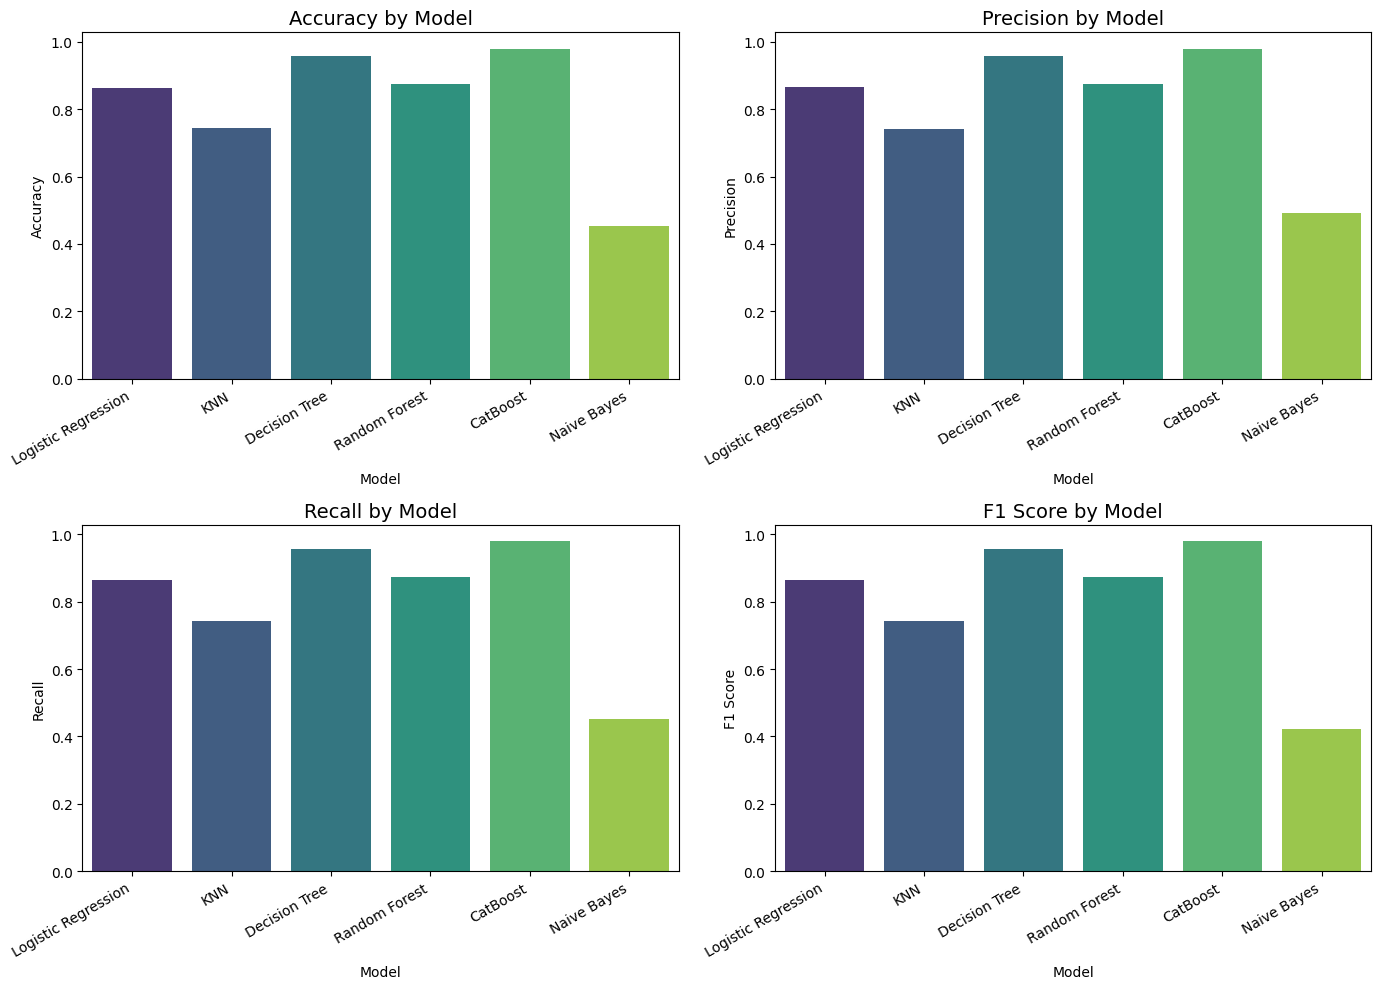

In [63]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

plt.figure(figsize=(14, 10))
for i, metric in enumerate(metrics, 1):
    plt.subplot(2, 2, i)  # 2 rows, 2 columns
    sns.barplot(data=metrics_df, x='Model', y=metric, palette='viridis')
    plt.title(f'{metric} by Model', fontsize=14)
    plt.xlabel('Model')
    plt.ylabel(metric)
    plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.show()


This code block creates a 3x2 grid of confusion matrices, one for each of your six trained models, allowing for a direct visual comparison of their prediction errors.

First, plt.subplots(3, 2, ...) creates a figure with a grid of six empty plots (3 rows, 2 columns) and returns them in a 2D array called axes. The .flatten() method then converts this 2D array into a simple 1D array, making it easy to loop through.

Second, the code loops through your best_models dictionary. In each loop, it uses the current model to make predictions on the X_test data.

Third, ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[i], ...) calculates the confusion matrix and plots it directly onto the designated subplot (axes[i]) in the grid.

Finally, any unused subplots (if you had fewer than six models) are hidden with fig.delaxes(), and plt.tight_layout() cleans up the spacing before plt.show() displays the entire 3x2 grid.

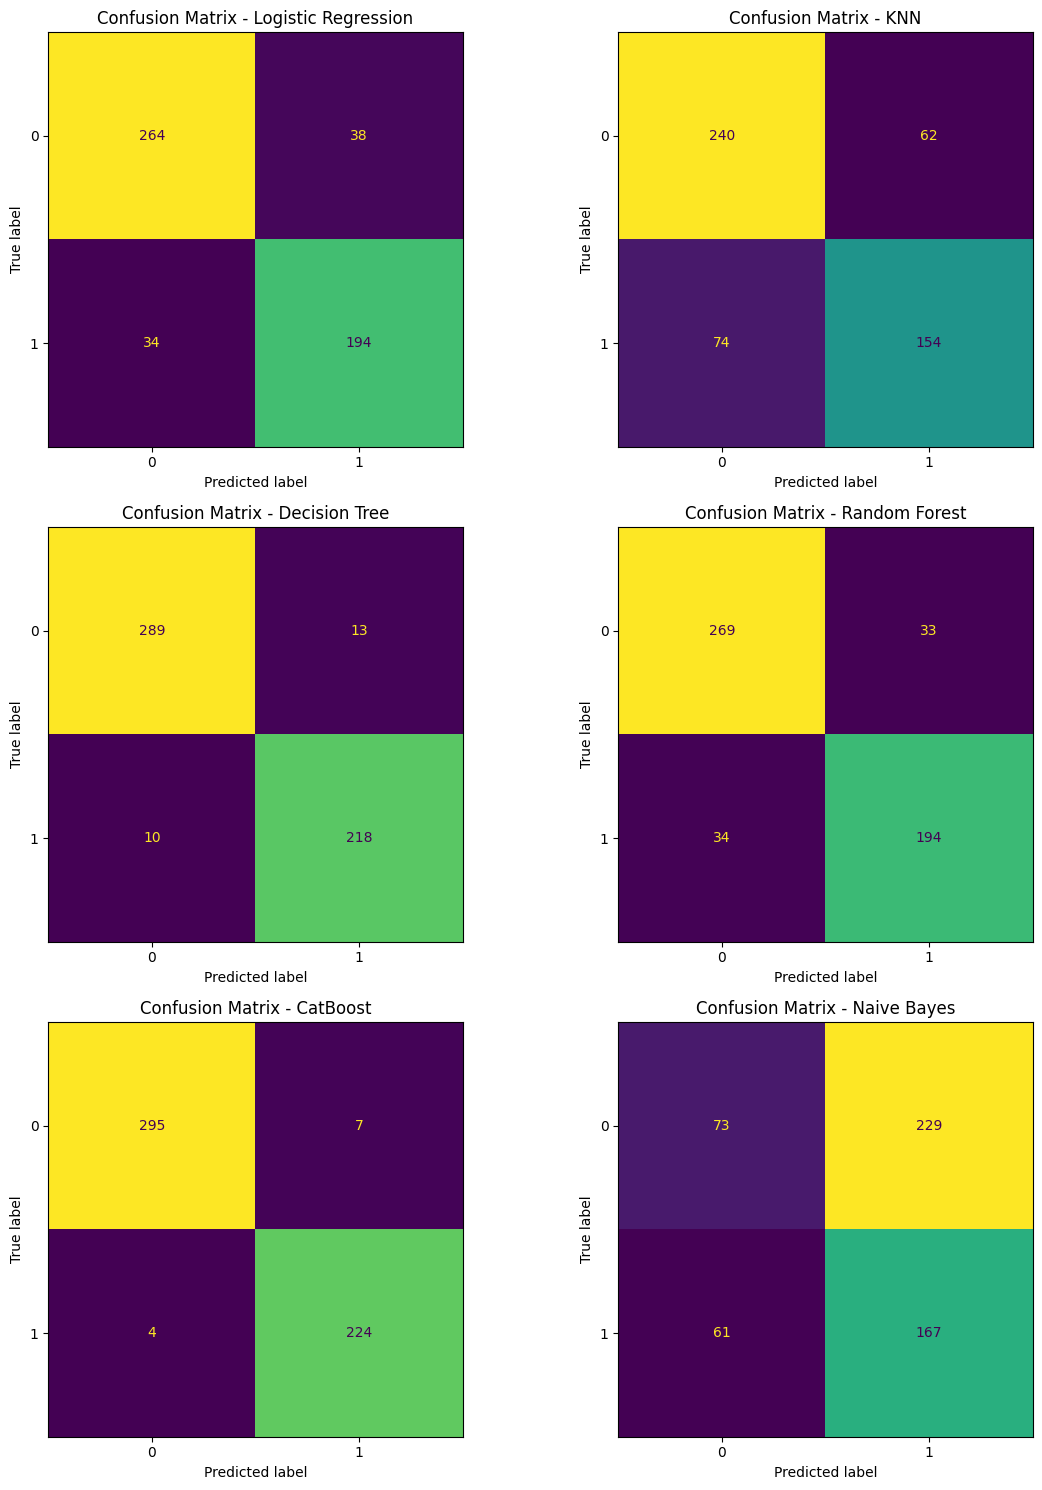

In [64]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create a 3x2 grid
fig, axes = plt.subplots(3, 2, figsize=(12, 15))
axes = axes.flatten()  # Flatten to easily iterate through

for i, (name, model) in enumerate(best_models.items()):
    if i >= 6:
        break
    y_pred = model.predict(X_test)
    disp = ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, ax=axes[i], colorbar=False
    )
    axes[i].set_title(f'Confusion Matrix - {name}', fontsize=12)

for j in range(i + 1, 6):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()



This code evaluates the final CatBoost model ⚡. It first retrieves the best-tuned CatBoost model from the best_models dictionary and second, uses it to .predict() outcomes on the unseen X_test data. Finally, it prints a comprehensive classification_report by comparing the model's predictions (y_pred_catboost) to the actual correct answers (y_test), showing key performance metrics like precision, recall, and f1-score for both the "Satisfied" and "Not Satisfied" classes.

In [65]:
from sklearn.metrics import classification_report

# Predict using the CatBoost model
y_pred_catboost = best_models["CatBoost"].predict(X_test)

# Print classification report
print("\n⚡ CatBoost Model Performance:")
print(classification_report(y_test, y_pred_catboost))


⚡ CatBoost Model Performance:
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       302
           1       0.97      0.98      0.98       228

    accuracy                           0.98       530
   macro avg       0.98      0.98      0.98       530
weighted avg       0.98      0.98      0.98       530



## Step 4: Explainability

In [66]:
import shap
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

def explain_with_shap(model_name, best_models, X_test, sample_size=20):
    """
    Robust SHAP explanation pipeline.
    Supports tree, linear, and kernel-based models with clean global + local visualization.
    """

    # --- Step 1: Load model and sanity check ---
    if model_name not in best_models:
        raise ValueError(f"Model '{model_name}' not found in best_models.")
    model = best_models[model_name]
    print(f"\n🔍 Generating SHAP explanations for {model_name}...")

    # --- Step 2: Extract classifier and scaler if pipeline ---
    if hasattr(model, "named_steps") and "clf" in model.named_steps:
        clf = model.named_steps["clf"]
        scaler = model.named_steps.get("scaler", None)
    else:
        clf = model
        scaler = None

    # --- Step 3: Prepare data ---
    X_used = scaler.transform(X_test) if scaler else (X_test.values if hasattr(X_test, "values") else X_test)
    X_sample_df = X_test.sample(min(sample_size, len(X_test)), random_state=42)
    X_sample = scaler.transform(X_sample_df) if scaler else X_sample_df.values

    # --- Step 4: Select appropriate SHAP explainer ---
    tree_models = ("Random Forest", "Decision Tree", "CatBoost", "Gradient Boosting")
    linear_models = ("Linear Regression", "Logistic Regression")

    if any(m in model_name for m in tree_models):
        explainer = shap.TreeExplainer(clf)
        shap_values = explainer(X_sample_df)
    elif any(m in model_name for m in linear_models):
        explainer = shap.LinearExplainer(clf, X_sample_df)
        shap_values = explainer(X_sample_df)
    else:
        # Generic models (KNN, Naive Bayes, etc.)
        background = shap.utils.sample(X_sample_df, min(100, X_sample_df.shape[0]), random_state=42)
        try:
            explainer = shap.KernelExplainer(clf.predict_proba, background)
            shap_values_raw = explainer.shap_values(X_sample_df)
            shap_values = shap_values_raw if isinstance(shap_values_raw, list) else [shap_values_raw]
        except Exception as e:
            print(f"⚠️ Kernel explainer failed: {e}")
            shap_values = None

    # --- Step 5: Global Explanation ---
    print("✅ SHAP values computed. Generating global summary plot...")
    plt.figure(figsize=(10, 6))
    try:
        if shap_values is None:
            print("⚠️ Global SHAP summary skipped — SHAP values unavailable.")
        elif isinstance(shap_values, list) and hasattr(shap_values[0], "values"):
            shap.summary_plot(shap_values[0].values, X_sample_df, feature_names=X_sample_df.columns, show=False)
        elif isinstance(shap_values, list):
            shap.summary_plot(shap_values[0], X_sample_df, feature_names=X_sample_df.columns, show=False)
        else:
            shap.summary_plot(shap_values.values, X_sample_df, feature_names=X_sample_df.columns, show=False)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"⚠️ Error during global SHAP plotting: {e}")

    # --- Step 6: Local Explanation ---
    try:
        if shap_values is None:
            print("⚠️ Local explanation skipped — SHAP values unavailable.")
            return

        shap.initjs()
        i = 0  # explain the first test sample
        print(f"🔹 Generating local explanation for row {i}...")

        # Handle both multi-class and single-output cases
        if isinstance(shap_values, list):
            class_index = 1 if len(shap_values) > 1 else 0
            base_value = (
                explainer.expected_value[class_index]
                if hasattr(explainer, "expected_value")
                else explainer.expected_values[class_index]
            )
            values = shap_values[class_index][i]
        else:
            base_value = getattr(shap_values, "base_values", [None])[i]
            values = getattr(shap_values, "values", [None])[i]

        # Some models (e.g., KNN) produce arrays that break SHAP's force plot
        if isinstance(values, np.ndarray) and len(values.shape) > 1:
            print("⚠️ Local force plot skipped (unsupported SHAP value format).")
            return

        # Display force plot in HTML (good for VS Code notebooks)
        force_plot_html = shap.force_plot(
            base_value,
            values,
            X_sample_df.iloc[i],
            feature_names=X_sample_df.columns,
            matplotlib=False,
        )
        display(HTML(f"<div style='width:100%; overflow-x:auto;'>{force_plot_html.html()}</div>"))

    except Exception as e:
        print(f"⚠️ Local explanation skipped due to: {e}")

    print("✅ SHAP explanation complete!\n")


### Model Explainability with SHAP

This code block defines a Python function `explain_with_shap` that uses the SHAP (SHapley Additive exPlanations) library to explain the predictions of a machine learning model. SHAP is a powerful tool for understanding how individual features contribute to a model's output, both globally across the dataset and locally for specific predictions.

Here's a breakdown of the function's steps:

1.  **Load Model and Sanity Check:** It first retrieves the specified model from the `best_models` dictionary and ensures it exists.
2.  **Extract Classifier and Scaler:** It checks if the model is part of a scikit-learn `Pipeline` and extracts the final classifier and any `StandardScaler` that might have been used for preprocessing.
3.  **Prepare Data:** It prepares a sample of the test data (`X_test`) for explanation. This sampling is done to make the computation of SHAP values more efficient, especially for large datasets.
4.  **Select SHAP Explainer:** It intelligently chooses the appropriate SHAP explainer based on the type of the underlying classifier (Tree-based, Linear, or other generic models). Different explainer types are optimized for different model architectures.
5.  **Global Explanation:** It computes SHAP values for the sampled data and generates a global summary plot. This plot visualizes the overall impact and direction of each feature on the model's predictions across the sampled dataset.
6.  **Local Explanation:** It generates a local explanation for a specific instance (the first row of the sampled data in this case) using a force plot. This plot shows how each feature's value for that specific instance pushes the prediction from the base value (average prediction) towards the final predicted value.

In essence, this function provides a robust way to gain insights into your model's decision-making process by showing which features are most influential and how they affect individual predictions.


🔍 Generating SHAP explanations for CatBoost...
✅ SHAP values computed. Generating global summary plot...


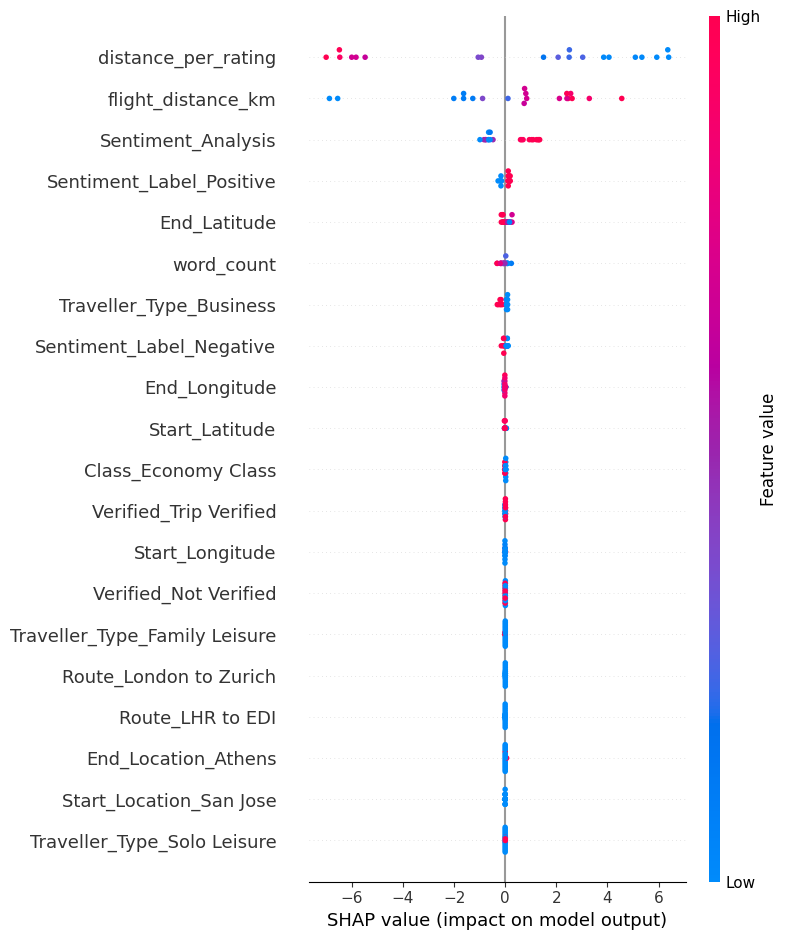

🔹 Generating local explanation for row 0...


✅ SHAP explanation complete!



In [67]:
  # Example: explain the trained CatBoost or Random Forest model
explain_with_shap("CatBoost", best_models, X_test)

In [70]:
from lime.lime_tabular import LimeTabularExplainer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML


def explain_with_lime(model_name, best_models, X_train, X_test, y_train, sample_size=20):
    """
    Explain model predictions using LIME.
    Structured similar to SHAP's architecture with robust visualization handling for VS Code notebooks.
    """

    if model_name not in best_models:
        raise ValueError(f"Model '{model_name}' not found in best_models dictionary.")

    model = best_models[model_name]
    print(f"\n🔍 Generating LIME explanations for {model_name}...")

    # --- Step 1: Retrieve classifier & scaler ---
    if hasattr(model, "named_steps") and "clf" in model.named_steps:
        clf = model.named_steps["clf"]
        scaler = model.named_steps.get("scaler", None)
    else:
        clf = model
        scaler = None

    # --- Step 2: Prepare data ---
    if scaler:
        X_train_used = scaler.transform(X_train)
        X_test_used = scaler.transform(X_test)
    else:
        X_train_used = X_train.values if hasattr(X_train, "values") else X_train
        X_test_used = X_test.values if hasattr(X_test, "values") else X_test

    # Subsample for efficiency
    if sample_size and X_test_used.shape[0] > sample_size:
        sample_idx = np.random.choice(X_test_used.shape[0], sample_size, replace=False)
        X_sample = X_test_used[sample_idx]
        X_sample_df = X_test.iloc[sample_idx]
    else:
        X_sample = X_test_used
        X_sample_df = X_test

    # --- Step 3: Initialize LIME explainer ---
    explainer = LimeTabularExplainer(
        training_data=X_train_used,
        feature_names=X_train.columns,
        class_names=np.unique(y_train).astype(str),
        mode='classification'
    )

    print("✅ LIME explainer initialized.")

    # --- Step 4: Local Explanation (visual) ---
    try:
        i = 0  # First row for consistency
        print(f"\n🔹 Generating local explanation for row {i}...")

        exp = explainer.explain_instance(
            X_test_used[i],
            clf.predict_proba,
            num_features=10
        )

        # Try the HTML visualization first
        try:
            display(HTML(exp.as_html()))
        except Exception:
            print("⚠️ Could not render HTML visualization — falling back to matplotlib.")
            fig = exp.as_pyplot_figure()
            plt.title(f"LIME Local Explanation for {model_name} (row {i})")
            plt.tight_layout()
            plt.show()

    except Exception as e:
        print(f"⚠️ Local explanation skipped due to: {e}")

    print("✅ LIME explanation complete!\n")


In [72]:
explain_with_lime("CatBoost", best_models, X_train, X_test, y_train)


🔍 Generating LIME explanations for CatBoost...
✅ LIME explainer initialized.

🔹 Generating local explanation for row 0...


✅ LIME explanation complete!



### 🔍 Interpreting the LIME Explanation (CatBoost Model)

This visualization explains **why the CatBoost model predicted class `1` with ~99% probability** for a specific test instance.

---

#### **1. Prediction Summary**
- **Predicted Class:** `1`
- **Prediction Probabilities:**
  - Class **0:** 0.01  
  - Class **1:** 0.99  
  → The model is **very confident** this instance belongs to class `1`.

---

#### **2. Feature Contributions**
The bars on the right show how individual features influenced the prediction.

- **🟧 Orange bars** → Push the prediction **toward class 1**  
- **🔵 Blue bars** → Push the prediction **toward class 0**

Each bar’s length represents **how strongly** that feature affected the local decision.

---

#### **3. Key Drivers in This Example**
- **Strong positive contributors (favoring class 1):**
  - `Route_London Gatwick to Malaga`
  - `Route_Madrid to Belfast via London`
  - `Route_MIA to BRU via LHR`

- **Negative contributors (favoring class 0):**
  - `Route_Marseille to Seattle via London Heathrow`
  - `Layover_Route_London / Singapore`
  - `Route_LCY to Granada`
  - `Start_Location_Islamabad`
  - `End_Location_Paris Orly`

These features collectively shaped the local decision boundary that LIME built around this instance.

---

#### **4. How to Read It**
- The **model associates certain routes or locations** with higher probability of belonging to class `1`.  
- Routes in **orange** increased the model’s confidence in class `1`.  
- Routes in **blue** decreased that confidence, but not enough to outweigh the positive features.

---

#### **5. Takeaway**
This LIME output helps you understand **which travel routes or locations most influenced CatBoost’s prediction** for this specific example.  
It doesn’t generalize globally but gives a **faithful local explanation** around that individual prediction.

---

✅ **In short:**  
The CatBoost model predicted class `1` with high confidence mainly because of certain travel routes (e.g., *London Gatwick → Malaga*) that strongly pushed the prediction toward class `1`, while other routes slightly pulled it toward class `0`.
